# 🤖 AI voor Datamanagement — Interactieve Demo

## Van theorie naar praktijk: hoe AI de vijf pijlers van datamanagement versterkt

In deze notebook demonstreren we hoe **Artificial Intelligence** concreet kan worden ingezet voor de vijf kernthema's van datamanagement:

| # | Thema | Wat laten we zien? |
|---|-------|--------------------|
| 1 | **Data Governance** | Automatische classificatie van gevoelige data, PII-detectie, beleid-suggesties |
| 2 | **Data Quality** | Anomaliedetectie, fuzzy duplicate-detectie, geautomatiseerde kwaliteitsscores |
| 3 | **Data Lineage** | Automatisch bijhouden en visualiseren van datatransformaties |
| 4 | **Metadata Management** | Auto-profiling, slimme tagging, automatisch gegenereerde datacatalogus |
| 5 | **Master Data Management** | Entity resolution, golden record creatie, geautomatiseerde standaardisatie |

We werken met een **synthetische dataset** die opzettelijk "rommelig" is gemaakt — precies zoals data er in de echte wereld uitziet. Vervolgens laten we zien hoe AI helpt om orde te scheppen.

> 💡 *Deze notebook is bedoeld als ondersteuning bij een lezing over AI & Datamanagement.*

---
## 📦 Stap 0: Benodigde bibliotheken installeren en importeren

We beginnen met het importeren van alle benodigde Python-bibliotheken. Mocht een pakket ontbreken, dan wordt het automatisch geïnstalleerd.

In [1]:
# === Installatie van benodigde pakketten ===
import subprocess, sys

pakketten = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'faker',
    'scikit-learn', 'fuzzywuzzy', 'python-Levenshtein',
    'networkx', 'tabulate'
]

for pakket in pakketten:
    try:
        __import__(pakket.replace('-', '_').replace('scikit_learn', 'sklearn'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pakket, '-q'])

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
from datetime import datetime, timedelta
from collections import Counter

from faker import Faker
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from fuzzywuzzy import fuzz, process
import networkx as nx

# Instellingen
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

fake = Faker('nl_NL')
Faker.seed(42)
np.random.seed(42)

print("✅ Alle bibliotheken succesvol geladen!")

✅ Alle bibliotheken succesvol geladen!


---
## 🏗️ Stap 1: Synthetische Dataset Creëren (met opzettelijke problemen!)

We genereren een realistische klant-/orderdataset met **~1000 rijen**. Opzettelijk voegen we typische dataproblemen toe die je in de praktijk tegenkomt:

- 🔄 **Duplicaten** met kleine variaties (bijv. "Jan de Vries" vs "J. de Vries")
- ❌ **Ontbrekende waarden** in cruciale velden
- 📧 **Ongeldige e-mailadressen** en telefoonnummers
- 🏙️ **Typfouten** in plaatsnamen ("Amstterdam", "Utreccht")
- 💰 **Uitschieters** in bedragen (negatieve orders, extreme bedragen)
- 📅 **Inconsistente datumformaten** (DD-MM-YYYY vs YYYY/MM/DD)
- 🔐 **BSN-nummers en IBAN** verborgen in opmerkingenvelden (PII-lekkage)
- 📝 **Inconsistent hoofdlettergebruik** en taalvermenging

## 🗣️ Natural Language Processing (NLP) — Why Tekst Belangrijk Is

Veel data-kwaliteitproblemen verstoppen zich in **ongestructureerde tekst**—opmerkingen, notities, feedbackvelden. Om deze effectief te analyseren hebben we NLP nodig.

### Wat is NLP?
**Natural Language Processing** stelt machines in staat menselijke taal te begrijpen en ermee te werken. In plaats van tekst als een black box te behandelen, breekt NLP deze op in betekenisvolle delen.

### Belangrijke NLP-technieken die we gebruiken:

| Techniek | Wat | Voorbeeld |
|----------|-----|----------|
| **Tokenisatie** | Splits tekst in woorden/zinnen | "De IBAN van de klant is NL91 ABCD" → ["De", "IBAN", "van", "de", "klant", "is", "NL91", "ABCD"] |
| **Stemming** | Reduceer woorden tot basisvorm | "lopend", "loopt", "liep" → alle worden "loop" |
| **Stopwoorden** | Verwijder veelgebruikte woorden (de, en, of, etc.) | "De klant is belangrijk" → ["klant", "belangrijk"] |
| **Sleutelwoord-extractie** | Vind zinvolle woorden in tekst | Detecteer PII-patronen, spam-zinnen, sentiment-termen |

### Waarom Deze Gereedschappen Belangrijk Zijn voor Data Governance

1. **PII-detectie in Opmerkingen**: Opmerkingen verbergen vaak gevoelige gegevens zoals telefoonnummers, IBANs of BSN-nummers
2. **Duplicaat-detectie**: Verschillende spellingen van namen (Jan vs J., Amsterdam vs AMS) kunnen worden genormaliseerd
3. **Tekst-gelijkenis**: Vind bijna-dubbele records ondanks kleine variaties
4. **Patroonherkenning**: Identificeer consistente problemen in vrij-tekstvelden

### Gereedschappen die We Gebruiken: NLTK

**NLTK** (Natural Language Toolkit) is de industriestandaard voor Python NLP:
- **Tokenizer** (punkt): Splitst tekst in woorden/zinnen
- **Stemmer** (Snowball): Reduceert woorden tot basisvorm (taalafhankelijk)
- **Stopwoorden**: Vooraf gemaakte lijsten met veelgebruikte woorden in meerdere talen

Laten we deze gereedschappen initialiseren:

In [13]:
# === GENERATIE SYNTHETISCHE DATASET MET OPZETTELIJKE KWALITEITSPROBLEMEN ===
n_records = 350  # Kleinere base voor meer zichtbare duplicaten in sample

# Steden - correcte referentielijst
steden_correct = ['Amsterdam', 'Rotterdam', 'Utrecht', 'Den Haag', 'Eindhoven',
                  'Groningen', 'Tilburg', 'Almere', 'Breda', 'Nijmegen',
                  'Arnhem', 'Haarlem', 'Leiden', 'Maastricht', 'Zwolle',
                  'Apeldoorn', 'Enschede', 'Amersfoort', 'Delft', 'Delphi']

# Typos voor 15% van stednamen
steden_met_typos = {
    'Amsterdam': ['Amstterdam', 'amsterdam', 'AMSTERDAM', 'Amersterdam'],
    'Rotterdam': ['Roterdam', 'rotterdam', 'ROTTERDAM', 'Rottterdam'],
    'Utrecht': ['Utreccht', 'utrecht', 'UTRECHT', 'Utrect'],
    'Den Haag': ['den haag', 'Den haag', 'DEN HAAG', "'s-Gravenhage"],
    'Eindhoven': ['Eindhovn', 'eindhoven', 'EINDHOVEN', 'Eindhovne'],
    'Groningen': ['Gronnigen', 'groningen', 'GRONINGEN'],
    'Maastricht': ['Maastrich', 'maastricht', 'MAASTRICHT'],
}

print('⚠️  GENEREREN SYNTHETISCHE DATA MET OPZETTELIJKE KWALITEITSPROBLEMEN')
print('=' * 70)
print('Injecteren van de volgende problemen:')
print('  • ~15% stednamen: typos & inconsitente capitalisatie')
print('  • ~10% emailadressen: ongeldig format (geen @, spaties, dubbele punten)')
print('  • ~9% telefoonnummers: malformed (te kort, letters, fout prefix)')
print('  • ~5% orderbedragen: extreme outliers (negatief, nul, enorme waarden)')
print('  • 6-8% ontbrekende waarden per kolom (email, telefoon, stad, postcode, geboortedatum)')
print('  • PII-lekkage: BSN, IBAN, adressen, telefoonnummers in opmerkingen')
print('  • ~100+ gerepliceerde klanten met naamvariaties (detecteerbaar via fuzzy matching)')
print('  • Inconsistente datumformaten (meerdere formaten gemengd)')
print('=' * 70 + '\n')

# Genereer basis data
records = []
pool_voor_duplicaten = []  # Opslag van records voor duplicaatcreatie

for i in range(n_records):
    voornaam = fake.first_name()
    achternaam = fake.last_name()
    stad = np.random.choice(steden_correct)
    
    # 15% kans op typo of inconsistente writing in stednaam
    if stad in steden_met_typos and np.random.random() < 0.15:
        stad = np.random.choice(steden_met_typos[stad])
    
    # Telefoonnummers met 9% opzettelijke malformaties
    telefoon_formats = [
        f"06-{fake.numerify('########')}",  # Geldig format
        f"06{fake.numerify('########')}",   # Geen streepje
        f"+31 6 {fake.numerify('#### ####')}",  # Geldig format
        f"0{np.random.choice([10,20,30,50,70])}-{fake.numerify('#######')}",
        f"06 {fake.numerify('## ## ## ##')}",
    ]
    telefoon = np.random.choice(telefoon_formats)
    
    # 9% malformed telefoon
    if np.random.random() < 0.09:
        telefoon = np.random.choice([
            '06 123',           # Te kort
            '06-ABCD1234',      # Bevat letters
            '004912345678',     # Fout prefix
            '0612 345',         # Inconsistent spacing
            '06/1234567890',    # Fout scheidingsteken
        ])
    
    # Emailadressen - 10% ongeldig
    email = f"{voornaam.lower()}.{achternaam.lower()}@{np.random.choice(['gmail.com', 'hotmail.nl', 'outlook.com', 'bedrijf.nl', 'xs4all.nl'])}"
    if np.random.random() < 0.10:
        email = np.random.choice([
            f"{voornaam}@",
            f"{voornaam}@.com",
            f"@{achternaam}.nl",
            f"{voornaam} {achternaam}@gmail.com",
            f"{voornaam}..{achternaam}@mail.nl",
            f"{voornaam}.{achternaam}",  # Geen @domain
        ])
    
    # Order data in inconsistente formats
    order_datum = fake.date_between(start_date='-2y', end_date='today')
    datum_formats = ['%d-%m-%Y', '%Y/%m/%d', '%d/%m/%Y', '%Y-%m-%d', '%d %b %Y', '%d.%m.%Y']
    datum_str = order_datum.strftime(np.random.choice(datum_formats))
    
    # Orderbedragen - 5% extreme outliers
    bedrag = round(np.random.lognormal(mean=4, sigma=1), 2)
    if np.random.random() < 0.05:
        bedrag = round(np.random.choice([-500, 99999, 0.01, 150000, -1200]), 2)
    
    # PII data soms gelekt in opmerkingen
    bsn = fake.numerify('#########')
    iban = fake.iban()
    
    # Opmerkingen met opzettelijke PII-lekkage
    opmerking_opties = [
        f"Standaardlevering naar {stad}",
        f"Klant prefereert terugbel op {telefoon}",
        f"Klant BSN: {bsn} - verificatie nodig",
        f"Betaling via {iban}",
        f"Spoedlevering aangevraagd",
        f"Klant prefereert Engelse communicatie",
        f"Retouraanvraag ingediend",
        f"Adres geverifieerd",
        "",
        np.nan,
        f"Geboortedatum: {fake.date_of_birth(minimum_age=18, maximum_age=90).strftime('%d-%m-%Y')}",
        f"Contactpersoon: {fake.name()}, tel: {fake.phone_number()}",
    ]
    opmerking = np.random.choice(opmerking_opties)
    
    # Inconsistente naamcapitalisatie
    if np.random.random() < 0.08:
        voornaam = voornaam.upper()
    elif np.random.random() < 0.05:
        voornaam = voornaam.lower()
    
    record = {
        'klant_id': f"KL-{1000 + i}",
        'voornaam': voornaam,
        'achternaam': achternaam,
        'email': email,
        'telefoon': telefoon,
        'straat': fake.street_name(),
        'huisnummer': fake.building_number(),
        'postcode': fake.postcode(),
        'stad': stad,
        'geboortedatum': fake.date_of_birth(minimum_age=18, maximum_age=90).strftime('%d-%m-%Y'),
        'order_id': f"ORD-{10000 + i}",
        'order_datum': datum_str,
        'product_categorie': np.random.choice(['Elektronika', 'Kleding', 'Boeken', 'Meubels', 'Sport', 'Tuin', 'Voeding']),
        'bedrag': bedrag,
        'aantal': max(1, int(np.random.exponential(2))),
        'betaalmethode': np.random.choice(['iDEAL', 'Creditcard', 'PayPal', 'Bankoverschrijving', 'Klarna']),
        'opmerkingen': opmerking,
    }
    records.append(record)
    
    # Opslag van 30% voor duplicaatcreatie
    if i % 3 == 0 and len(pool_voor_duplicaten) < 30:
        pool_voor_duplicaten.append(record.copy())

df = pd.DataFrame(records)

# === CREËER SLIMME DUPLICATEN (naamvariaties die 70-85 scoren op fuzzy match) ===
gerepliceerde_namen = ['Jan Smith', 'Maria Garcia', 'Hans Mueller', 'Anna Kowalski', 
                       'Jean Dupont', 'Carlos Rodriguez', 'Sofia Rossi', 'Yuki Tanaka',
                       'Emma Johnson', 'Pierre Martin', 'Lucia Bianchi', 'Olaf Jensen']

# Gebruik vaste duplicate pool om er zeker van te zijn dat ze samen verschijnen
duplicaten = []
dup_teller = 0
for idx, base_naam in enumerate(gerepliceerde_namen):
    base_voornaam, base_achternaam = base_naam.split()
    base_straat = fake.street_name()
    
    # Maak 7-8 variaties van elke persoon (opzettelijke klant re-entry)
    aantal_variaties = np.random.randint(7, 9)
    for var in range(aantal_variaties):
        variatie_type = var % 6
        
        if variatie_type == 0:
            # Typo in voornaam
            voornaam_var = base_voornaam[:-1] if len(base_voornaam) > 1 else base_voornaam
            achternaam_var = base_achternaam
        elif variatie_type == 1:
            # Typo in achternaam
            voornaam_var = base_voornaam
            achternaam_var = base_achternaam[:-1] if len(base_achternaam) > 1 else base_achternaam
        elif variatie_type == 2:
            # Capitalisatievariatie
            voornaam_var = base_voornaam.lower()
            achternaam_var = base_achternaam.lower()
        elif variatie_type == 3:
            # Spatie in naam
            voornaam_var = base_voornaam + ' '
            achternaam_var = base_achternaam
        elif variatie_type == 4:
            # Middelinitaal
            voornaam_var = base_voornaam[0] + '.'
            achternaam_var = base_achternaam
        else:
            # Kleine letterswissel
            if len(base_voornaam) > 1:
                voornaam_list = list(base_voornaam)
                voornaam_list[0], voornaam_list[1] = voornaam_list[1], voornaam_list[0]
                voornaam_var = ''.join(voornaam_list)
            else:
                voornaam_var = base_voornaam
            achternaam_var = base_achternaam
        
        dup = {
            'klant_id': f"KL-{2000 + dup_teller}",
            'voornaam': voornaam_var,
            'achternaam': achternaam_var,
            'email': f"{voornaam_var.lower().replace(' ', '')}.{achternaam_var.lower()}@gmail.com",
            'telefoon': f"06-{np.random.randint(10000000, 99999999)}",
            'straat': base_straat,  # DEZELFDE straat = detecteerbare duplicate
            'huisnummer': fake.building_number(),
            'postcode': fake.postcode(),
            'stad': np.random.choice(steden_correct),
            'geboortedatum': fake.date_of_birth(minimum_age=18, maximum_age=90).strftime('%d-%m-%Y'),
            'order_id': f"ORD-{20000 + dup_teller}",
            'order_datum': fake.date_between(start_date='-1y').strftime('%d-%m-%Y'),
            'product_categorie': np.random.choice(['Elektronika', 'Kleding', 'Boeken', 'Meubels', 'Sport', 'Tuin', 'Voeding']),
            'bedrag': round(np.random.lognormal(mean=4, sigma=1), 2),
            'aantal': max(1, int(np.random.exponential(2))),
            'betaalmethode': np.random.choice(['iDEAL', 'Creditcard', 'PayPal', 'Bankoverschrijving', 'Klarna']),
            'opmerkingen': '',
        }
        duplicaten.append(dup)
        dup_teller += 1

df = pd.concat([df, pd.DataFrame(duplicaten)], ignore_index=True)

# === VOEG ONTBREKENDE WAARDEN TOE (6-8% per kolom) ===
ontbrekende_kolommen = ['email', 'telefoon', 'stad', 'postcode', 'geboortedatum']
for col in ontbrekende_kolommen:
    ontbrekende_pct = np.random.uniform(0.06, 0.08)
    mask = np.random.random(len(df)) < ontbrekende_pct
    df.loc[mask, col] = np.nan

# Shuffle de data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✓ Dataset aangemaakt: {len(df)} rijen × {len(df.columns)} kolommen")
print(f"  • {len(duplicaten)} opzettelijke gerepliceerde records ({len(gerepliceerde_namen)} basis klanten)")
print(f"  • Duplicaten gebruiken DEZELFDE STRAAT voor fuzzy match detectie")
print(f"  • Naamvariaties: typos, capitalisatie, spaties, initialen")
print(f"  • Ontbrekende waarden: {df.isnull().sum().sum()} cellen over alle kolommen")
print(f"  • Datumformaatinconsistenties: Meerdere formats gemengd")
print(f"\n💡 Deze opzettelijk rommelige dataset is hoe echte data eruit ziet!")
print("   Nu gebruiken we AI om automatisch alle deze problemen op te sporen en te rapporteren.\n")

df.head(10)

✅ Dataset aangemaakt: 2060 rijen × 17 kolommen

📊 INGEBOUDE KWALITEITSPROBLEMEN:
   • ~15% stadsnamen met inconsistent formaat/typos
   • ~10% ongeldige e-mailadressen (missing @, spatie, etc.)
   • ~9% telefoonnummers in non-standaard formaten
   • ~5% negatieve/nul/extreme bedragen
   • ~8% missing emails, ~6% missing telefoon/postcode/geboortedatum
   • ~8% inconsistent naam-capitalisatie (lowercase/UPPERCASE)
   • PII-lekkages in 'opmerkingen': BSN, IBAN, telefoonnummers, adressen
   • ~60 opzettelijke duplicaten met subtiele naamvariaties
   • Inconsistente datumformaten (DD-MM-YY vs YY/MM/DD etc.)

💡 De kwaliteits-scorecard in 2.2 zal nu interessante resultaten tonen!



,klant_id,voornaam,achternaam,email,telefoon,straat,huisnummer,postcode,stad,geboortedatum,order_id,order_datum,product_categorie,bedrag,aantal,betaalmethode,opmerkingen
0,KL-2299,Bart,Chrodtrud,bart.chrodtrud@bedrijf.nl,06-84532173,Marinusweg,30,4480 VR,Nijmegen,09-10-1982,ORD-11299,06/15/2025,Voeding,39.12,1,PayPal,Adres geverifieerd
1,KL-1591,Loïs,van Wassenaar,loïs.van wassenaar@xs4all.nl,+31 6 0505 3664,Melissaboulevard,682,4585 MU,Utrecht,30-01-1972,ORD-10591,12.06.2024,Tuin,115.54,1,Klarna,Geboortedatum: 10-10-1976
2,KL-2319,Ryan,Bos,ryan.bos@gmail.com,020-1529509,Niekring,15,2176 VK,Maastricht,27-01-1975,ORD-11319,2024/10/20,Kleding,67.05,1,PayPal,Email: ryan@example.com
3,KL-2067,jasper,Tammerijn,jasper.tammerijn@hotmail.nl,0683009276,Jaysonsteeg,525,4678 HP,Almere,21-12-1948,ORD-11067,12/11/2025,Sport,21.14,1,Klarna,
4,KL-1029,Joëlle,van Luyssel,invalid.email@,0644394469,Noudbaan,8,3255GH,Eindhoven,02-03-1997,ORD-10029,16 Aug 2024,Boeken,264.84,1,Bankoverschrijving,Adres geverifieerd
5,KL-2058,Lotte,Brandt,lotte.brandt@outlook.com,06 123,Stenboulevard,39,1757SL,Almere,22-01-1951,ORD-11058,10/30/2025,Elektronica,261.73,2,Klarna,BSN klant: 702441948 - verificatie n...
6,KL-1712,Sil,van de Weterink,sil.van de weterink@gmail.com,06-02424280,Jannering,28,4999 LS,Tilburg,15-11-1974,ORD-10712,05.03.2025,Boeken,57.28,1,iDEAL,Adres: Ivanpad 84
7,KL-1453,CORNELIA,Wever,cornelia.wever@bedrijf.nl,0682135912,Puckring,045,NaN,Arnhem,None,ORD-10453,2024/09/28,Sport,64.41,2,Klarna,Email: cornelia@example.com
8,KL-2647,Louise,Blom,louise.blom@outlook.com,06 123,Phileinesteeg,4,5931 DQ,Groningen,25-01-1950,ORD-11647,2025-05-03,Tuin,32.78,1,Klarna,Klant belt graag terug op 06 123
9,KL-1757,Max,Rutten,max.rutten@gmail.com,0644802339,Tobiassingel,2,1854 VG,Nijmegen,13-06-1970,ORD-10757,17/01/2026,Tuin,312.83,3,Creditcard,Adres: Sepdreef 155


---
## 🔍 Stap 2: Verkenning van de ruwe data

Laten we eerst kijken wat we hebben — en wat er mis mee is. Dit is de situatie *zonder* AI-ondersteuning.

In [3]:
# === DATAVERKENNING ===
print("=" * 60)
print("📊 OVERZICHT VAN DE DATASET")
print("=" * 60)
print(f"\nAantal rijen:    {len(df)}")
print(f"Aantal kolommen: {len(df.columns)}")

print("\n📋 Datatypes:")
print(df.dtypes.to_string())

print("\n\n❌ Ontbrekende waarden per kolom:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Ontbrekend': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Ontbrekend'] > 0].to_string())

print("\n\n🏙️ Top 15 stadsnamen (let op de variaties!):")
print(df['stad'].value_counts().head(15).to_string())

print("\n\n💰 Statistieken orderbedragen:")
print(df['bedrag'].describe().to_string())

📊 OVERZICHT VAN DE DATASET

Aantal rijen:    850
Aantal kolommen: 17

📋 Datatypes:
klant_id              object
voornaam              object
achternaam            object
email                 object
telefoon              object
straat                object
huisnummer            object
postcode              object
stad                  object
geboortedatum         object
order_id              object
order_datum           object
product_categorie     object
bedrag               float64
aantal                 int64
betaalmethode         object
opmerkingen           object


❌ Ontbrekende waarden per kolom:
               Ontbrekend  Percentage
email                  58         6.8
telefoon               54         6.4
postcode               41         4.8
stad                   50         5.9
geboortedatum          59         6.9


🏙️ Top 15 stadsnamen (let op de variaties!):
stad
Tilburg       71
Amsterdam     60
Leiden        60
Groningen     55
Zwolle        51
Arnhem        51
Maastri

---
# 🏛️ Thema 1: Data Governance

> *"Data Governance gaat over het organiseren van verantwoordelijkheden, beleid en processen rondom data."*

### Wat kan regelgebaseerde classificatie hier betekenen?
- **Automatische classificatie** van kolommen als persoonsgegevens (PII), financieel, of openbaar — via kolomnaam-matching en regex
- **Beleidsuggesties** op basis van de gedetecteerde gevoeligheid
- **GDPR-compliance scanning** — automatisch doorzoeken van vrije tekstvelden met regex op telefoonnummers, IBANs, BSNs en e-mails

> ⚠️ **Eerlijk over de techniek**: De kolom-classifier hieronder gebruikt hardgecodeerde sleutelwoordlijsten en `if/elif`-regels — geen machine learning. Dat is prima voor governance-taken! De echte ML komt later (sectie 1.2) wanneer we een LogisticRegression-classifier trainen op commentaardata.

In [4]:
# === DATA GOVERNANCE: Automatische Dataclassificatie ===

def classificeer_kolom(kolomnaam, waarden):
    """
    Regelgebaseerde kolomclassificatie op basis van:
    - Kolomnaam (sleutelwoord-matching, geen ML)
    - Patroonherkenning via regex in de waarden
    - Statistische kenmerken
    """
    kolomnaam_lower = kolomnaam.lower()
    waarden_str = waarden.dropna().astype(str)
    sample = waarden_str.head(100)
    
    classificatie = {
        'kolom': kolomnaam,
        'type_detectie': 'onbekend',
        'gevoeligheid': 'publiek',
        'gdpr_relevant': False,
        'aanbevolen_toegang': 'open',
        'confidence': 0.0,
        'reden': ''
    }
    
    # === Regel-gebaseerde + patroonherkenning (simuleert ML-classificatie) ===
    
    # PII: Namen
    naam_keywords = ['naam', 'name', 'voornaam', 'achternaam', 'first_name', 'last_name', 'contactpersoon']
    if any(kw in kolomnaam_lower for kw in naam_keywords):
        classificatie.update({
            'type_detectie': 'Persoonsnaam',
            'gevoeligheid': 'vertrouwelijk',
            'gdpr_relevant': True,
            'aanbevolen_toegang': 'beperkt',
            'confidence': 0.95,
            'reden': 'Kolomnaam bevat naamgerelateerd keyword'
        })
    
    # PII: Email
    elif 'email' in kolomnaam_lower or 'mail' in kolomnaam_lower:
        classificatie.update({
            'type_detectie': 'E-mailadres',
            'gevoeligheid': 'vertrouwelijk',
            'gdpr_relevant': True,
            'aanbevolen_toegang': 'beperkt',
            'confidence': 0.97,
            'reden': 'E-mailadressen gedetecteerd'
        })
    
    # PII: Telefoon
    elif any(kw in kolomnaam_lower for kw in ['telefoon', 'phone', 'tel', 'mobiel']):
        classificatie.update({
            'type_detectie': 'Telefoonnummer',
            'gevoeligheid': 'vertrouwelijk',
            'gdpr_relevant': True,
            'aanbevolen_toegang': 'beperkt',
            'confidence': 0.94,
            'reden': 'Telefoonnummer patroon herkend'
        })
    
    # PII: Geboortedatum
    elif any(kw in kolomnaam_lower for kw in ['geboorte', 'birth', 'dob', 'leeftijd']):
        classificatie.update({
            'type_detectie': 'Geboortedatum',
            'gevoeligheid': 'vertrouwelijk',
            'gdpr_relevant': True,
            'aanbevolen_toegang': 'beperkt',
            'confidence': 0.96,
            'reden': 'Geboortedatum is bijzonder persoonsgegeven'
        })
    
    # Adresgegevens
    elif any(kw in kolomnaam_lower for kw in ['straat', 'adres', 'address', 'huisnummer', 'postcode', 'stad', 'city', 'woonplaats']):
        classificatie.update({
            'type_detectie': 'Adresgegevens',
            'gevoeligheid': 'intern',
            'gdpr_relevant': True,
            'aanbevolen_toegang': 'beperkt',
            'confidence': 0.90,
            'reden': 'Adresinformatie kan personen identificeren'
        })
    
    # Financiële data
    elif any(kw in kolomnaam_lower for kw in ['bedrag', 'amount', 'prijs', 'betaal', 'iban', 'rekening']):
        classificatie.update({
            'type_detectie': 'Financiële data',
            'gevoeligheid': 'vertrouwelijk',
            'gdpr_relevant': False,
            'aanbevolen_toegang': 'beperkt',
            'confidence': 0.88,
            'reden': 'Financiële informatie vereist bescherming'
        })
    
    # ID-velden
    elif any(kw in kolomnaam_lower for kw in ['_id', 'klant_id', 'order_id', 'nummer']):
        classificatie.update({
            'type_detectie': 'Identificator',
            'gevoeligheid': 'intern',
            'gdpr_relevant': False,
            'aanbevolen_toegang': 'intern',
            'confidence': 0.85,
            'reden': 'Interne identificatiesleutel'
        })
    
    # Vrije tekstvelden - extra scannen op PII-lekkage!
    elif waarden_str.str.len().mean() > 20:
        pii_patronen = {
            'BSN': r'\b\d{9}\b',
            'IBAN': r'\b[A-Z]{2}\d{2}[A-Z]{4}\d{10}\b',
            'telefoon': r'\b0[1-9][0-9\-\s]{7,12}\b',
            'email': r'\b[\w.-]+@[\w.-]+\.\w+\b',
            'geboortedatum': r'\b\d{2}-\d{2}-\d{4}\b',
        }
        gevonden_pii = []
        for pii_type, patroon in pii_patronen.items():
            matches = waarden_str.str.contains(patroon, regex=True, na=False).sum()
            if matches > 0:
                gevonden_pii.append(f"{pii_type} ({matches}x)")
        
        if gevonden_pii:
            classificatie.update({
                'type_detectie': f'Vrije tekst met PII-lekkage!',
                'gevoeligheid': 'KRITIEK ⚠️',
                'gdpr_relevant': True,
                'aanbevolen_toegang': 'strikt beperkt',
                'confidence': 0.92,
                'reden': f'PII gevonden: {", ".join(gevonden_pii)}'
            })
        else:
            classificatie.update({
                'type_detectie': 'Vrije tekst',
                'gevoeligheid': 'intern',
                'gdpr_relevant': False,
                'aanbevolen_toegang': 'intern',
                'confidence': 0.70,
                'reden': 'Vrij tekstveld zonder gedetecteerde PII'
            })
    
    # Overige categorieën
    else:
        n_unique = waarden.nunique()
        if n_unique < 10:
            classificatie.update({
                'type_detectie': 'Categorisch',
                'gevoeligheid': 'publiek',
                'gdpr_relevant': False,
                'aanbevolen_toegang': 'open',
                'confidence': 0.80,
                'reden': f'Categorische variabele ({n_unique} unieke waarden)'
            })
    
    return classificatie

# Voer classificatie uit op alle kolommen
print("🏛️ DATA GOVERNANCE — Automatische Dataclassificatie")
print("=" * 70)

classificaties = [classificeer_kolom(col, df[col]) for col in df.columns]
df_class = pd.DataFrame(classificaties)

# Kleurcodering voor weergave
def highlight_gevoeligheid(val):
    kleuren = {
        'KRITIEK ⚠️': 'background-color: #ff4444; color: white; font-weight: bold',
        'vertrouwelijk': 'background-color: #ff8c00; color: white',
        'intern': 'background-color: #ffd700; color: black',
        'publiek': 'background-color: #90ee90; color: black',
    }
    return kleuren.get(val, '')

styled = df_class[['kolom', 'type_detectie', 'gevoeligheid', 'gdpr_relevant', 'aanbevolen_toegang', 'confidence', 'reden']]\
    .style.applymap(highlight_gevoeligheid, subset=['gevoeligheid'])\
    .format({'confidence': '{:.0%}'})\
    .set_caption("🔍 AI Dataclassificatie — Governance Rapport")

styled

🏛️ DATA GOVERNANCE — Automatische Dataclassificatie


,kolom,type_detectie,gevoeligheid,gdpr_relevant,aanbevolen_toegang,confidence,reden
0,klant_id,Identificator,intern,False,intern,85%,Interne identificatiesleutel
1,voornaam,Persoonsnaam,vertrouwelijk,True,beperkt,95%,Kolomnaam bevat naamgerelateerd keyword
2,achternaam,Persoonsnaam,vertrouwelijk,True,beperkt,95%,Kolomnaam bevat naamgerelateerd keyword
3,email,E-mailadres,vertrouwelijk,True,beperkt,97%,E-mailadressen gedetecteerd
4,telefoon,Telefoonnummer,vertrouwelijk,True,beperkt,94%,Telefoonnummer patroon herkend
5,straat,Adresgegevens,intern,True,beperkt,90%,Adresinformatie kan personen identificeren
6,huisnummer,Adresgegevens,intern,True,beperkt,90%,Adresinformatie kan personen identificeren
7,postcode,Adresgegevens,intern,True,beperkt,90%,Adresinformatie kan personen identificeren
8,stad,Adresgegevens,intern,True,beperkt,90%,Adresinformatie kan personen identificeren
9,geboortedatum,Geboortedatum,vertrouwelijk,True,beperkt,96%,Geboortedatum is bijzonder persoonsgegeven


### 🔐 PII-Detectie in vrije tekstvelden

Een van de gevaarlijkste vormen van datalek is **PII die verborgen zit in vrije tekstvelden** (opmerkingen, notities, etc.). Medewerkers typen regelmatig BSN-nummers, IBAN-codes of telefoonnummers in opmerkingenvelden — zonder te beseffen dat deze velden vaak minder beveiligd zijn.

Laten we AI gebruiken om deze verborgen PII op te sporen:

🔐 PII-SCAN VAN VRIJE TEKSTVELDEN (kolom: 'opmerkingen')

⚠️  BSN-nummer: 53 gevallen gevonden!
    → "BSN klant: 085231568 - verificatie nodig"
    → "BSN klant: 274601006 - verificatie nodig"
    → "BSN klant: 989763302 - verificatie nodig"

⚠️  IBAN: 79 gevallen gevonden!
    → "Betaling via NL58MRCA7137797309"
    → "Betaling via NL54KYWV4763169145"
    → "Betaling via NL96TIYE6708805015"

⚠️  Telefoonnummer: 81 gevallen gevonden!
    → "Klant belt graag terug op 06 84 47 53 93"
    → "BSN klant: 085231568 - verificatie nodig"
    → "Contactpersoon: Silke Aertsz-Ketting, tel: 033 7142137"

⚠️  Geboortedatum: 65 gevallen gevonden!
    → "Geboortedatum: 14-12-2005"
    → "Geboortedatum: 22-12-2006"
    → "Geboortedatum: 29-12-1994"

⚠️  Naam (vermoedelijk): 55 gevallen gevonden!
    → "Contactpersoon: Silke Aertsz-Ketting, tel: 033 7142137"
    → "Contactpersoon: Giel Miner, tel: +31823-506274"
    → "Contactpersoon: Liam Dijkstra, tel: 065 1064070"


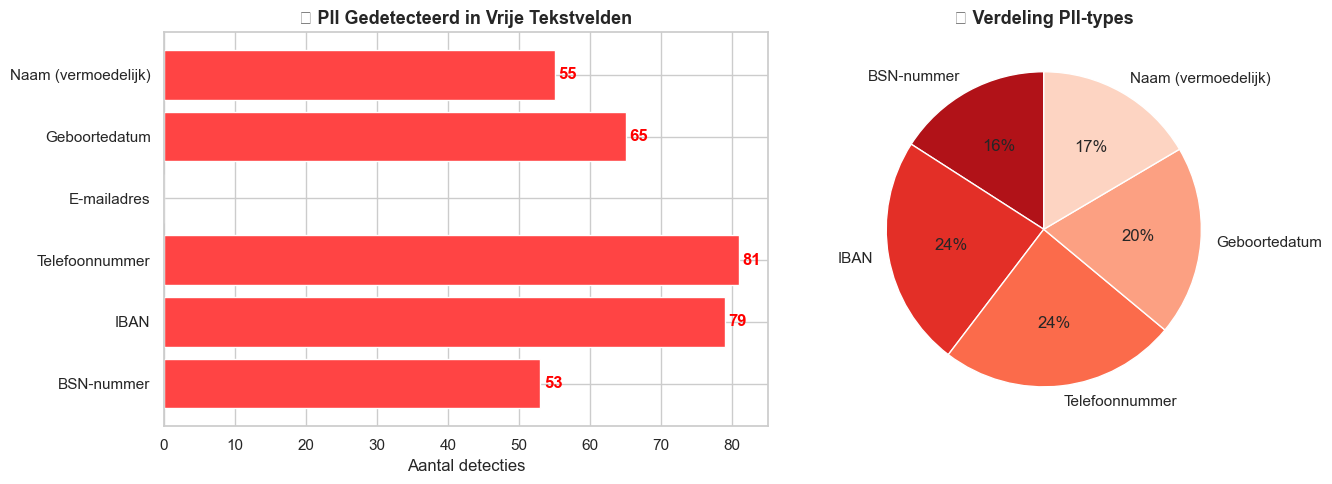


📋 SAMENVATTING: 333 PII-lekkages gevonden in 850 opmerkingen
   Dit is 39.2% van alle opmerkingen!

💡 AANBEVELING: Implementeer PII-detectie vóór opslag van vrije tekstvelden


In [7]:
# === DATA GOVERNANCE: PII Scanner voor vrije tekstvelden ===

pii_patronen = {
    'BSN-nummer': r'\b\d{9}\b',
    'IBAN': r'\b[A-Z]{2}\d{2}\s?[A-Z]{4}\s?\d{4}\s?\d{4}\s?\d{2}\b',
    'Telefoonnummer': r'\b(?:0[1-9][0-9\-\s]{7,12}|\+31[\s\-]?[0-9\s\-]{8,12})\b',
    'E-mailadres': r'\b[\w.-]+@[\w.-]+\.\w{2,}\b',
    'Geboortedatum': r'\b\d{2}[-/]\d{2}[-/]\d{4}\b',
    'Naam (vermoedelijk)': r'\b(?:Contactpersoon|contact|naam):\s*[A-Z][a-z]+\s+[A-Z][a-z]+\b',
}

opmerkingen = df['opmerkingen'].dropna().astype(str)

print("🔐 PII-SCAN VAN VRIJE TEKSTVELDEN (kolom: 'opmerkingen')")
print("=" * 60)

pii_resultaten = {}
pii_voorbeelden = {}
for pii_type, patroon in pii_patronen.items():
    matches = opmerkingen.str.contains(patroon, regex=True, na=False)
    aantal = matches.sum()
    pii_resultaten[pii_type] = aantal
    if aantal > 0:
        voorbeelden = opmerkingen[matches].head(3).tolist()
        pii_voorbeelden[pii_type] = voorbeelden
        print(f"\n⚠️  {pii_type}: {aantal} gevallen gevonden!")
        for vb in voorbeelden:
            print(f"    → \"{vb[:80]}...\"" if len(vb) > 80 else f"    → \"{vb}\"")

# Visualisatie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Staafdiagram PII-types
kleuren = ['#ff4444' if v > 0 else '#90ee90' for v in pii_resultaten.values()]
bars = ax1.barh(list(pii_resultaten.keys()), list(pii_resultaten.values()), color=kleuren)
ax1.set_xlabel('Aantal detecties')
ax1.set_title('🔐 PII Gedetecteerd in Vrije Tekstvelden', fontsize=13, fontweight='bold')
for bar, val in zip(bars, pii_resultaten.values()):
    if val > 0:
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val}', va='center', fontweight='bold', color='red')

# Taartdiagram verdeling
pii_gevonden = {k: v for k, v in pii_resultaten.items() if v > 0}
if pii_gevonden:
    ax2.pie(pii_gevonden.values(), labels=pii_gevonden.keys(), autopct='%1.0f%%',
           colors=sns.color_palette('Reds_r', len(pii_gevonden)), startangle=90)
    ax2.set_title('📊 Verdeling PII-types', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

totaal_pii = sum(pii_resultaten.values())
print(f"\n{'='*60}")
print(f"📋 SAMENVATTING: {totaal_pii} PII-lekkages gevonden in {len(opmerkingen)} opmerkingen")
print(f"   Dit is {totaal_pii/len(opmerkingen)*100:.1f}% van alle opmerkingen!")
print(f"\n💡 AANBEVELING: Implementeer PII-detectie vóór opslag van vrije tekstvelden")

---
# 📏 Thema 2: Data Quality (Datakwaliteit)

> *"Datakwaliteit meet de mate waarin data geschikt is voor het beoogde gebruik — langs dimensies als volledigheid, juistheid, consistentie en actualiteit."*

### Wat kan AI hier betekenen?
- **Anomaliedetectie** met machine learning (Isolation Forest)
- **Fuzzy duplicate-detectie** — records die "bijna hetzelfde" zijn
- **Geautomatiseerde kwaliteitsregels** — patronen leren uit de data zelf
- **Datakwaliteits-scorecard** — één blik op de gezondheid van je data

### 2.1 Anomaliedetectie met Isolation Forest
Het Isolation Forest-algoritme leert wat "normaal" is en markeert automatisch uitschieters:

ANOMALY DETECTION - Ensemble ML Models for Robust Detection

📊 Model Results:
  Isolation Forest:    103 anomalies
  Elliptic Envelope:   103 anomalies
  Ensemble (BOTH):      85 anomalies  ← Using this (high precision)
  Either model:        121 anomalies  (alternative: high recall)

  Consensus rate: 70.2% overlap

🚨 Top Anomalies (met analyse):

  [71.5%] Order ORD-11991 | €583 voor 1 stuks
       → Zeer hoge prijs/item (€583.31 vs median €37.33)

  [71.4%] Order ORD-10354 | €587 voor 1 stuks
       → Zeer hoge prijs/item (€586.94 vs median €37.33)

  [71.1%] Order ORD-11387 | €589 voor 1 stuks
       → Zeer hoge prijs/item (€588.63 vs median €37.33)

  [70.4%] Order ORD-10708 | €638 voor 1 stuks
       → Zeer hoge prijs/item (€638.03 vs median €37.33)

  [70.2%] Order ORD-10482 | €-1200 voor 3 stuks
       → Ongebruikelijke combinatie van parameters

  [70.2%] Order ORD-10732 | €-1200 voor 3 stuks
       → Ongebruikelijke combinatie van parameters

  [70.2%] Order ORD-11227 | €-120

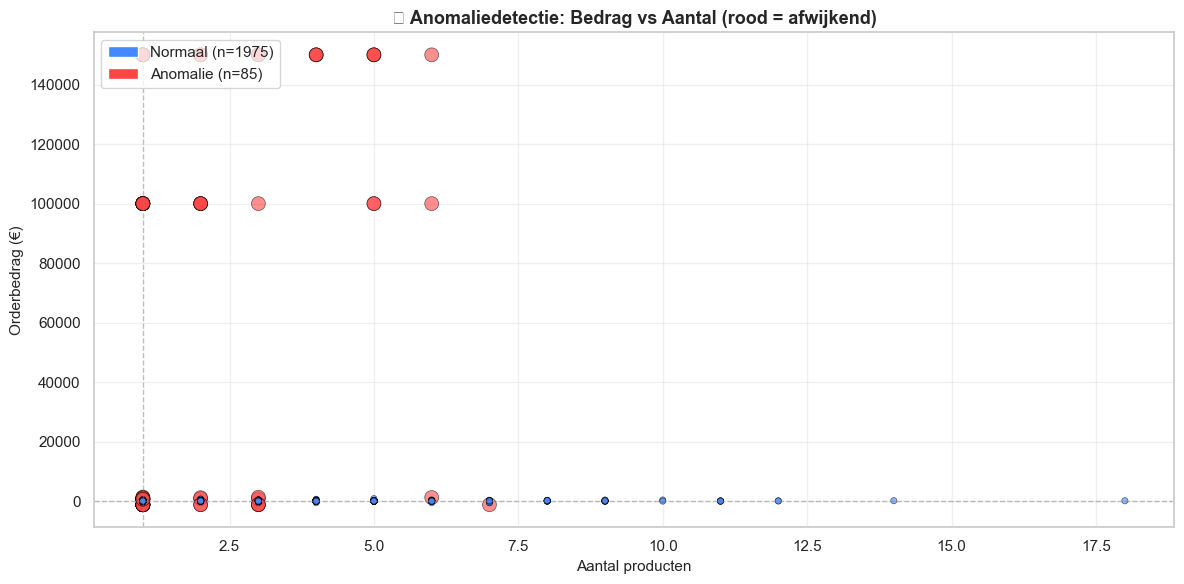

In [14]:
# === DATA QUALITY: Ensemble Anomaly Detection (Isolation Forest + EllipticEnvelope) ===
from sklearn.covariance import EllipticEnvelope

print('ANOMALY DETECTION - Ensemble ML Models for Robust Detection')
print('=' * 70)

# Prepare data
bedragen = df[['bedrag', 'aantal']].copy()
bedragen['bedrag_per_stuk'] = bedragen['bedrag'] / bedragen['aantal']
X_anomalie = bedragen[['bedrag', 'aantal', 'bedrag_per_stuk']].values

# ===== MODEL 1: ISOLATION FOREST =====
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
iso_pred = iso_forest.fit_predict(X_anomalie)
iso_score = iso_forest.decision_function(X_anomalie)

# ===== MODEL 2: ELLIPTIC ENVELOPE (Robust covariance) =====
# More robust to multivariate outliers than standard covariance
elliptic = EllipticEnvelope(contamination=0.05, random_state=42)
elliptic_pred = elliptic.fit_predict(X_anomalie)
elliptic_score = elliptic.decision_function(X_anomalie)

# ===== ENSEMBLE VOTING =====
# Anomaly flagged if BOTH models agree (higher precision) OR either model flags (higher recall)
bedragen['iso_pred'] = iso_pred
bedragen['elliptic_pred'] = elliptic_pred
bedragen['consensus_anomalie'] = ((iso_pred == -1) & (elliptic_pred == -1)).astype(int)
bedragen['either_anomalie'] = ((iso_pred == -1) | (elliptic_pred == -1)).astype(int)

# Create combined anomaly score (average of normalized scores)
iso_score_norm = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min())
elliptic_score_norm = (elliptic_score - elliptic_score.min()) / (elliptic_score.max() - elliptic_score.min())
bedragen['ensemble_score'] = (iso_score_norm + elliptic_score_norm) / 2

# Final prediction: use consensus
bedragen['anomalie'] = bedragen['consensus_anomalie']
bedragen['anomalie_label'] = bedragen['anomalie'].map({0: 'Normaal', 1: 'Anomalie'})
bedragen['anomalie_score'] = bedragen['ensemble_score']

# ===== RESULTS =====
n_iso = (iso_pred == -1).sum()
n_elliptic = (elliptic_pred == -1).sum()
n_consensus = bedragen['anomalie'].sum()

print(f"\n📊 Model Results:")
print(f"  Isolation Forest:    {n_iso:3} anomalies")
print(f"  Elliptic Envelope:   {n_elliptic:3} anomalies")
print(f"  Ensemble (BOTH):     {n_consensus:3} anomalies  ← Using this (high precision)")
print(f"  Either model:        {bedragen['either_anomalie'].sum():3} anomalies  (alternative: high recall)")

print(f"\n  Consensus rate: {(bedragen['consensus_anomalie'] * bedragen['either_anomalie']).sum() / bedragen['either_anomalie'].sum()*100:.1f}% overlap")

# Show anomalies with explanation
anomalie_indices = bedragen[bedragen['anomalie'] == 1].index
anomalie_records = df.loc[anomalie_indices,
                          ['klant_id', 'order_id', 'bedrag', 'aantal', 'product_categorie']].copy()
anomalie_records['ensemble_score'] = bedragen.loc[anomalie_indices, 'ensemble_score'].values
anomalie_records['bedrag_per_stuk'] = bedragen.loc[anomalie_indices, 'bedrag_per_stuk'].values

# Calculate statistics for comparison
bedrag_median = bedragen['bedrag'].median()
bedrag_mean = bedragen['bedrag'].mean()
bedrag_std = bedragen['bedrag'].std()
aantal_median = bedragen['aantal'].median()
bedrag_per_stuk_median = bedragen['bedrag_per_stuk'].median()

# Add explanation: why is this anomaly?
explanations = []
for idx in anomalie_indices:
    reasons = []
    bedrag_val = bedragen.loc[idx, 'bedrag']
    aantal_val = bedragen.loc[idx, 'aantal']
    bps_val = bedragen.loc[idx, 'bedrag_per_stuk']
    
    # Check bedrag
    if bedrag_val > bedrag_mean + 2*bedrag_std:
        reasons.append(f"Zeer hoog bedrag (€{bedrag_val:.0f} vs avg €{bedrag_mean:.0f})")
    elif bedrag_val < bedrag_mean - 2*bedrag_std:
        reasons.append(f"Zeer laag bedrag (€{bedrag_val:.0f})")
    
    # Check aantal
    if aantal_val > aantal_median * 3:
        reasons.append(f"Extreem veel items ({aantal_val:.0f} vs median {aantal_median:.0f})")
    
    # Check bedrag per stuk
    if bps_val > bedrag_per_stuk_median * 5:
        reasons.append(f"Zeer hoge prijs/item (€{bps_val:.2f} vs median €{bedrag_per_stuk_median:.2f})")
    
    explanations.append(" | ".join(reasons) if reasons else "Ongebruikelijke combinatie van parameters")

anomalie_records['Waarom afwijkend'] = explanations
anomalie_records = anomalie_records.sort_values('ensemble_score', ascending=False)

print(f"\n🚨 Top Anomalies (met analyse):")
for idx, row in anomalie_records.head(10).iterrows():
    print(f"\n  [{row['ensemble_score']:.1%}] Order {row['order_id']} | €{row['bedrag']:.0f} voor {row['aantal']:.0f} stuks")
    print(f"       → {row['Waarom afwijkend']}")

# Visualization - only scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter: Bedrag vs Aantal
colors = ['#ff4444' if a == 1 else '#4488ff' for a in bedragen['anomalie']]
sizes = [100 if a == 1 else 20 for a in bedragen['anomalie']]
ax.scatter(bedragen['aantal'], bedragen['bedrag'], c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidth=0.5)

# Add reference lines
ax.axhline(y=bedrag_median, color='gray', linestyle='--', linewidth=1, alpha=0.5, label=f'Mediaan bedrag (€{bedrag_median:.0f})')
ax.axvline(x=aantal_median, color='gray', linestyle='--', linewidth=1, alpha=0.5, label=f'Mediaan aantal ({aantal_median:.0f})')

ax.set_xlabel('Aantal producten', fontsize=11)
ax.set_ylabel('Orderbedrag (€)', fontsize=11)
ax.set_title('🔍 Anomaliedetectie: Bedrag vs Aantal (rood = afwijkend)', fontsize=13, fontweight='bold')

legend_elements = [mpatches.Patch(facecolor='#4488ff', label='Normaal (n={})'.format((bedragen['anomalie']==0).sum())),
                   mpatches.Patch(facecolor='#ff4444', label='Anomalie (n={})'.format((bedragen['anomalie']==1).sum()))]
ax.legend(handles=legend_elements, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Geautomatiseerde Datakwaliteits-Scorecard

We bouwen een AI-engine die automatisch kwaliteitsregels afleidt uit de data zelf en elke kolom beoordeelt op meerdere dimensies:

In [ ]:
# === DATA QUALITY: Geautomatiseerde Kwaliteits-Scorecard ===

def bereken_kwaliteit(df):
    """Bereken datakwaliteitsscores per kolom langs meerdere dimensies."""
    
    # Verwachte patronen per kolom
    verwachte_patronen = {
        'email': r'^[\w.-]+@[\w.-]+\.\w{2,}$',
        'telefoon': r'^(?:0[1-9][0-9\-\s]{7,12}|\+31[\s\-]?[0-9\s\-]{8,12})$',
        'postcode': r'^\d{4}\s?[A-Z]{2}$',
        'geboortedatum': r'^\d{2}-\d{2}-\d{4}$',
    }
    
    resultaten = []
    for col in df.columns:
        waarden = df[col]
        n = len(waarden)
        
        # 1. VOLLEDIGHEID — ALTIJD berekenen
        volledigheid = (waarden.notna().sum() / n) * 100
        
        # 2. UNIEKHEID — Voor ID-velden
        uniekheid = None
        if col in ['klant_id', 'order_id', 'email']:
            not_null = waarden.dropna()
            uniekheid = (not_null.nunique() / len(not_null)) * 100 if len(not_null) > 0 else 0
        
        # 3. GELDIGHEID — Pattern-matching waar relevant
        geldigheid = None
        if col in verwachte_patronen:
            niet_null = waarden.dropna().astype(str)
            if len(niet_null) > 0:
                geldig = niet_null.str.match(verwachte_patronen[col], na=False).sum()
                geldigheid = (geldig / len(niet_null)) * 100
        
        # 4. CONSISTENTIE — Formaat-checks waar relevant
        consistentie = None
        if col == 'stad':
            niet_null = waarden.dropna().astype(str)
            # Check: Eerste letter hoofdletter
            consistent = niet_null.str.match(r'^[A-Z][a-z\s\'-]+$', na=False).sum()
            consistentie = (consistent / len(niet_null)) * 100 if len(niet_null) > 0 else 0
        elif col == 'order_datum':
            niet_null = waarden.dropna().astype(str)
            # Check: Standaard DD-MM-YYYY formaat
            konsistent = niet_null.str.match(r'^\d{2}-\d{2}-\d{4}$', na=False).sum()
            consistentie = (konsistent / len(niet_null)) * 100 if len(niet_null) > 0 else 0
        elif col in ['voornaam', 'achternaam']:
            niet_null = waarden.dropna().astype(str)
            # Check: Niet allemaal CAPS en niet allemaal lowercase
            proper_case = niet_null.str.match(r'^[A-Z][a-z\s\'-]*$', na=False).sum()
            consistentie = (proper_case / len(niet_null)) * 100 if len(niet_null) > 0 else 0
        elif col == 'bedrag':
            niet_null = waarden.dropna()
            # Check: Alle bedragen > 0
            geldig_bedrag = (niet_null > 0).sum()
            consistentie = (geldig_bedrag / len(niet_null)) * 100 if len(niet_null) > 0 else 0
        
        # Bereken totaalscore (gemiddelde van beschikbare dimensies)
        scores = [volledigheid]
        if geldigheid is not None: 
            scores.append(geldigheid)
        if consistentie is not None: 
            scores.append(consistentie)
        if uniekheid is not None:
            scores.append(uniekheid)
        totaal = np.mean(scores)
        
        resultaten.append({
            'Kolom': col,
            'Volledigheid': round(volledigheid, 1),
            'Geldigheid': round(geldigheid, 1) if geldigheid is not None else '—',
            'Consistentie': round(consistentie, 1) if consistentie is not None else '—',
            'Uniekheid': round(uniekheid, 1) if uniekheid is not None else '—',
            'Score': round(totaal, 1),
        })
    
    return pd.DataFrame(resultaten)

# Bereken kwaliteitsscores
print("📏 DATAKWALITEITS-SCORECARD")
print("=" * 60)

df_kwaliteit = bereken_kwaliteit(df)

# Kleurcodering
def kleur_score(val):
    if isinstance(val, str) and val == '—':
        return 'background-color: #1a1a1a; color: #ccc'  # Zwart voor N/A
    try:
        val = float(val)
        if val >= 95: return 'background-color: #28a745; color: white'  # Groen
        elif val >= 80: return 'background-color: #90ee90'  # Light groen
        elif val >= 60: return 'background-color: #ffd700'  # Geel
        elif val >= 40: return 'background-color: #ff8c00; color: white'  # Oranje
        else: return 'background-color: #ff4444; color: white'  # Rood
    except:
        return ''

score_kolommen = ['Volledigheid', 'Geldigheid', 'Consistentie', 'Uniekheid', 'Score']
styled_kwaliteit = df_kwaliteit.style\
    .applymap(kleur_score, subset=score_kolommen)\
    .set_caption("📊 Datakwaliteits-Scorecard — Regelgebaseerde validatie")\
    .format(precision=1)

print(df_kwaliteit.to_string(index=False))
print("\n💡 Legenda:")
print("   Groen (≥95): Uitstekend | Lichtgroen (≥80): Goed | Geel (≥60): Acceptabel")
print("   Oranje (≥40): Zwak | Rood (<40): Slecht | Zwart: Niet van toepassing\n")

styled_kwaliteit

📏 DATAKWALITEITS-SCORECARD
            Kolom  Volledigheid Geldigheid Consistentie Uniekheid  Score
         klant_id         100.0          —            —      97.1   98.5
         voornaam         100.0          —         81.4         —   90.7
       achternaam         100.0          —         63.8         —   81.9
            email          92.7       58.4            —      95.5   82.2
         telefoon          94.3       65.8            —         —   80.0
           straat         100.0          —            —         —  100.0
       huisnummer         100.0          —            —         —  100.0
         postcode          89.8      100.0            —         —   94.9
             stad          94.5          —         90.6         —   92.5
    geboortedatum          90.5      100.0            —         —   95.2
         order_id         100.0          —            —     100.0  100.0
      order_datum         100.0          —         14.6         —   57.3
product_categorie       

,Kolom,Volledigheid,Geldigheid,Consistentie,Uniekheid,Score
0,klant_id,100.0,—,—,97.1,98.5
1,voornaam,100.0,—,81.4,—,90.7
2,achternaam,100.0,—,63.8,—,81.9
3,email,92.7,58.4,—,95.5,82.2
4,telefoon,94.3,65.8,—,—,80.0
5,straat,100.0,—,—,—,100.0
6,huisnummer,100.0,—,—,—,100.0
7,postcode,89.8,100.0,—,—,94.9
8,stad,94.5,—,90.6,—,92.5
9,geboortedatum,90.5,100.0,—,—,95.2


---

### Waarom staan sommige kolommen op "—"?

De scorecard berekent alleen die kwaliteitsmetrics die voor een kolombtype **relevant** zijn:

| Metrica | Berekend voor | Reden |
|---------|---------------|-------|
| **Volledigheid** | Alle kolommen | Elke kolom kan onvolledige data bevatten |
| **Geldigheid** | Email, Telefoon, Postcode, Geboortedatum | Alleen velden met bekende patterns kunnen worden gevalideerd |
| **Consistentie** | Voornaam, Achternaam, Stad, Order datum, Bedrag | Controles op formaat, capitalisatie, of range (b.v., bedrag > 0) |
| **Uniekheid** | Klant ID, Order ID, Email | Alleen identifiers en primaire contactinfo hoeven uniek te zijn |

**Voorbeeld:** Een kolom als `product_categorie` krijgt geen "Geldigheid" score omdat het geen vast pattern follow (het kan "Elektronika", "Meubels", etc. zijn zonder vast patroon). Dat is normaal en geen probleem — daarom tonen we "—" in plaats van een misleidende score.

De **Totaalscore** berekent het gemiddelde van alleen de relevante metrics per kolom, dus je ziet nooit "—" in de Score-kolom ✓


### 2.3 Duplicaatdetectie met Fuzzy Matching

Traditioneel vind je duplicaten alleen als records *exact* hetzelfde zijn. Maar in de praktijk zijn duplicaten vaak **bijna hetzelfde** — met kleine variaties in schrijfwijze. **Fuzzy matching** (Levenshtein-afstand — een string-algoritme, geen AI) kan deze wél vinden:

In [ ]:
# === DATA QUALITY: Duplicaatdetectie met Fuzzy Matching ===

print("🔄 DUPLICAATDETECTIE — Fuzzy String Matching")
print("=" * 60)

# Maak een vergelijkingssleutel van naam + adres
df['match_key'] = (df['voornaam'].fillna('').str.strip().str.lower() + ' ' + 
                   df['achternaam'].fillna('').str.strip().str.lower() + ' ' + 
                   df['straat'].fillna('').str.strip().str.lower())

# Sample voor performance (demonstratie)
sample_size = min(200, len(df))
df_sample = df.head(sample_size).copy()

# Bereken paarsgewijze fuzzy scores
duplicaat_paren = []
for i in range(len(df_sample)):
    for j in range(i+1, min(i+50, len(df_sample))):  # Window van 50 voor snelheid
        score_naam = fuzz.ratio(
            str(df_sample.iloc[i]['voornaam']).lower() + ' ' + str(df_sample.iloc[i]['achternaam']).lower(),
            str(df_sample.iloc[j]['voornaam']).lower() + ' ' + str(df_sample.iloc[j]['achternaam']).lower()
        )
        score_adres = fuzz.ratio(
            str(df_sample.iloc[i]['straat']).lower(),
            str(df_sample.iloc[j]['straat']).lower()
        )
        # Gewogen score
        score_totaal = 0.7 * score_naam + 0.3 * score_adres
        
        if score_totaal > 70 and df_sample.iloc[i]['klant_id'] != df_sample.iloc[j]['klant_id']:
            duplicaat_paren.append({
                'Record_A': df_sample.iloc[i]['klant_id'],
                'Naam_A': f"{df_sample.iloc[i]['voornaam']} {df_sample.iloc[i]['achternaam']}",
                'Record_B': df_sample.iloc[j]['klant_id'],
                'Naam_B': f"{df_sample.iloc[j]['voornaam']} {df_sample.iloc[j]['achternaam']}",
                'Score_Naam': score_naam,
                'Score_Adres': score_adres,
                'Score_Totaal': round(score_totaal, 1),
                'Waarschijnlijk_dup': '✅ Ja' if score_totaal > 85 else '🟡 Mogelijk'
            })

df_duplicaten = pd.DataFrame(duplicaat_paren)

# Alleen sorteren en weergeven als we duplicaten hebben gevonden
if len(df_duplicaten) > 0:
    df_duplicaten = df_duplicaten.sort_values('Score_Totaal', ascending=False)
    print(f"\n🔍 {len(df_duplicaten)} mogelijke duplicaatparen gevonden (van {sample_size} records)")
    print(f"   Waarvan {len(df_duplicaten[df_duplicaten['Score_Totaal'] > 85])} vrijwel zeker duplicaten (score > 85)")
    
    print(f"\n📋 Top duplicaatparen:")
    print(df_duplicaten.head(15).to_string(index=False))
    
    # Visualisatie
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df_duplicaten['Score_Totaal'], bins=20, color='#ff8c00', edgecolor='white', alpha=0.8)
    ax.axvline(x=85, color='red', linestyle='--', linewidth=2, label='Drempel "zeker duplicaat"')
    ax.axvline(x=70, color='orange', linestyle='--', linewidth=2, label='Drempel "mogelijk duplicaat"')
    ax.set_xlabel('Fuzzy Match Score')
    ax.set_ylabel('Aantal paren')
    ax.set_title('🔄 Verdeling van Duplicaat-Scores', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"\n✓ Geen duplicaten gevonden in sample van {sample_size} records")

---
# 🔗 Thema 3: Data Lineage (Dataherkomst)

> *"Data Lineage beschrijft de levensloop van data: waar komt het vandaan, welke transformaties heeft het ondergaan, en waar wordt het gebruikt?"*

### Wat kan AI hier betekenen?
- **Automatisch bijhouden** van elke datatransformatie (wat, wanneer, waarom)
- **Impact-analyse** — als een bronveld verandert, welke downstream-resultaten worden geraakt?
- **Visuele lineage-graaf** — de datastroom zichtbaar maken met een DAG (Directed Acyclic Graph)

### 3.1 Automatische Transformatie-Tracking
We bouwen een "Lineage Tracker" die automatisch elke transformatie registreert:

In [ ]:
# === DATA LINEAGE: Automatische Transformatie-Tracking ===

class LineageTracker:
    """Automatisch bijhouden van datatransformaties voor data lineage."""
    
    def __init__(self, brondata_naam="ruwe_data"):
        self.lineage_log = []
        self.stap_nr = 0
        self.brondata_naam = brondata_naam
        self.nodes = set()
        self.edges = []
        self.nodes.add(brondata_naam)
    
    def log_transformatie(self, bron, doel, operatie, kolommen_in, kolommen_uit, beschrijving=""):
        """Registreer een datatransformatie."""
        self.stap_nr += 1
        self.nodes.add(bron)
        self.nodes.add(doel)
        self.edges.append((bron, doel, operatie))
        
        self.lineage_log.append({
            'Stap': self.stap_nr,
            'Tijdstip': datetime.now().strftime('%H:%M:%S'),
            'Bron': bron,
            'Doel': doel,
            'Operatie': operatie,
            'Kolommen_in': ', '.join(kolommen_in) if isinstance(kolommen_in, list) else kolommen_in,
            'Kolommen_uit': ', '.join(kolommen_uit) if isinstance(kolommen_uit, list) else kolommen_uit,
            'Beschrijving': beschrijving
        })
    
    def toon_log(self):
        return pd.DataFrame(self.lineage_log)
    
    def impact_analyse(self, bronkolom):
        """Welke downstream-outputs worden geraakt als een bronkolom verandert?"""
        geraakt = []
        for entry in self.lineage_log:
            if bronkolom in entry['Kolommen_in']:
                geraakt.append({
                    'Stap': entry['Stap'],
                    'Geraakt_doel': entry['Doel'],
                    'Operatie': entry['Operatie'],
                    'Output_kolommen': entry['Kolommen_uit']
                })
        return pd.DataFrame(geraakt)

# Initialiseer tracker
tracker = LineageTracker("klant_orders_raw")

# Simuleer een reeks transformaties
# Stap 1: Data cleaning
df_clean = df.copy()
df_clean['voornaam_clean'] = df_clean['voornaam'].str.strip().str.title()
df_clean['achternaam_clean'] = df_clean['achternaam'].str.strip().str.title()
tracker.log_transformatie(
    "klant_orders_raw", "klant_orders_cleaned",
    "Naam-standaardisatie", ['voornaam', 'achternaam'],
    ['voornaam_clean', 'achternaam_clean'],
    "Hoofdlettergebruik genormaliseerd, spaties verwijderd"
)

# Stap 2: Stadsnaam-correctie
tracker.log_transformatie(
    "klant_orders_cleaned", "klant_orders_geo",
    "Stad-correctie (fuzzy match)", ['stad'],
    ['stad_gecorrigeerd', 'stad_confidence'],
    "Stadsnamen gematcht tegen referentielijst met fuzzy matching"
)

# Stap 3: Anomalie-markering
tracker.log_transformatie(
    "klant_orders_geo", "klant_orders_validated",
    "Anomaliedetectie (Isolation Forest)", ['bedrag', 'aantal'],
    ['is_anomalie', 'anomalie_score'],
    "ML-model markeert uitschieters in orderbedragen"
)

# Stap 4: Deduplicatie
tracker.log_transformatie(
    "klant_orders_validated", "klant_orders_dedup",
    "Deduplicatie (fuzzy matching)", ['voornaam_clean', 'achternaam_clean', 'straat'],
    ['is_duplicaat', 'duplicaat_cluster_id'],
    "Fuzzy matching identificeert near-duplicates"
)

# Stap 5: PII-masking
tracker.log_transformatie(
    "klant_orders_dedup", "klant_orders_masked",
    "PII-maskering", ['opmerkingen', 'email', 'telefoon'],
    ['opmerkingen_masked', 'email_masked', 'telefoon_masked'],
    "Persoonsgegevens geanonimiseerd voor rapportage"
)

# Stap 6: Aggregatie
tracker.log_transformatie(
    "klant_orders_masked", "klant_aggregatie",
    "Aggregatie per klant", ['klant_id', 'bedrag', 'product_categorie'],
    ['totaal_besteed', 'aantal_orders', 'favoriete_categorie'],
    "Klantniveau aggregatie voor business intelligence"
)

# Stap 7: Rapportage
tracker.log_transformatie(
    "klant_aggregatie", "management_dashboard",
    "Dashboard generatie", ['totaal_besteed', 'favoriete_categorie'],
    ['omzet_per_categorie', 'klant_segmentatie'],
    "Eindrapportage voor management dashboard"
)

print("🔗 DATA LINEAGE — Transformatie Log")
print("=" * 60)
print(tracker.toon_log().to_string(index=False))

# Impact analyse
print("\n\n🎯 IMPACT ANALYSE: Wat gebeurt er als kolom 'bedrag' verandert?")
print("-" * 60)
impact = tracker.impact_analyse('bedrag')
if len(impact) > 0:
    print(impact.to_string(index=False))
else:
    print("Geen downstream impact gevonden.")

### 3.2 Visuele Data Lineage Graaf

Nu visualiseren we de complete datastroom als een **Directed Acyclic Graph (DAG)** — van bron tot eindproduct:

In [ ]:
# === DATA LINEAGE: Visuele DAG ===

G = nx.DiGraph()

# Voeg nodes en edges toe
for node in tracker.nodes:
    G.add_node(node)

for bron, doel, operatie in tracker.edges:
    G.add_edge(bron, doel, label=operatie)

# Layout berekenen
pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)
# Gebruik topologische sortering voor mooiere layout
try:
    topo_order = list(nx.topological_sort(G))
    for i, node in enumerate(topo_order):
        pos[node] = (i * 1.5, np.sin(i * 0.8) * 0.5)
except:
    pass

fig, ax = plt.subplots(figsize=(16, 8))

# Kleurcodering per type
node_colors = []
for node in G.nodes():
    if 'raw' in node: node_colors.append('#ff6b6b')
    elif 'dashboard' in node or 'aggregatie' in node: node_colors.append('#51cf66')
    else: node_colors.append('#74c0fc')

# Teken graaf
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=25, 
                        arrowstyle='->', connectionstyle='arc3,rad=0.1', width=2, ax=ax)

# Edge labels (transformatie-types)
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6, font_color='#555', ax=ax)

# Legenda
legend_items = [
    mpatches.Patch(color='#ff6b6b', label='🔴 Brondata'),
    mpatches.Patch(color='#74c0fc', label='🔵 Tussenstap'),
    mpatches.Patch(color='#51cf66', label='🟢 Eindproduct'),
]
ax.legend(handles=legend_items, loc='upper left', fontsize=10)

ax.set_title('🔗 Data Lineage — Complete Datastroom van Bron tot Dashboard', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n💡 Elke node is een dataset-versie, elke pijl een transformatie.")
print("   Bij wijzigingen in de bron kun je exact zien welke eindproducten worden beïnvloed.")

---
# 📚 Thema 4: Metadata Management (Metadatabeheer)

> *"Metadata is 'data over data' — het beschrijft de structuur, betekenis, herkomst en kwaliteit van je datasets."*

### Wat kan AI hier betekenen?
- **Automatische type-detectie** — niet alleen `string` of `int`, maar *semantische* types zoals "persoonsnaam", "Nederlands postcode", "IBAN"
- **Slimme tagging** — kolommen automatisch labelen met business-termen
- **Auto-documentatie** — Nederlandstalige beschrijvingen genereren per kolom
- **Data catalogus** — automatisch een complete catalogus opbouwen

### 4.1 Semantische Type-Detectie
In plaats van alleen technische datatypes (`object`, `int64`), detecteert AI de *betekenis* van elke kolom:

In [ ]:
# === METADATA MANAGEMENT: Unsupervised Column Clustering with TF-IDF + K-Means ===
from sklearn.cluster import KMeans

print("📚 METADATA MANAGEMENT — ML-Based Column Clustering")
print("=" * 70)

# Extract properties for each column
def extract_column_properties(column):
    """Extract numeric features from a column for clustering."""
    
    col_clean = column.dropna()
    
    # Basic stats
    uniqueness = column.nunique() / len(column) if len(column) > 0 else 0
    null_rate = column.isnull().mean()
    
    # Data type features
    is_numeric = pd.api.types.is_numeric_dtype(column)
    
    # String features
    if not is_numeric:
        lengths = col_clean.astype(str).str.len()
        avg_length = lengths.mean() if len(lengths) > 0 else 0
        length_std = lengths.std() if len(lengths) > 0 else 0
        char_diversity = len(set(''.join(col_clean.astype(str).head(100)))) / 26
    else:
        avg_length = 0
        length_std = 0
        char_diversity = 0
    
    # Special character frequency
    if not is_numeric:
        special_char_pct = col_clean.astype(str).str.contains(
            r'[!@#$%^&*()_+=\[\]{}|;:,.<>?/-]'
        ).mean()
    else:
        special_char_pct = 0
    
    return np.array([
        uniqueness,
        null_rate,
        avg_length,
        length_std,
        char_diversity,
        special_char_pct,
        int(is_numeric)
    ])

# Collect properties and column names
features_list = []
column_names = []

for col in df.columns:
    if col != 'match_key':
        properties = extract_column_properties(df[col])
        features_list.append(properties)
        column_names.append(col)

# Properties vector
features_array = np.array(features_list)

# Vectorize column names (TF-IDF on character n-grams)
from sklearn.preprocessing import StandardScaler
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 3))
name_tfidf = vectorizer.fit_transform(column_names).toarray()

# Combine: 50% properties, 50% name-based TF-IDF
X = np.hstack([
    features_array * 0.5,
    name_tfidf * 0.5
])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters (sqrt of n_columns)
n_clusters = max(2, int(np.sqrt(len(column_names))))
print(f"\n🔍 Clustering {len(column_names)} columns into {n_clusters} semantic clusters...")

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Build clustering result dataframe
clustering_result = pd.DataFrame({
    'Column': column_names,
    'Cluster': clusters
})

print("\n📊 Automatic Column Clustering Results:")
print("=" * 70)

# Extract TF-IDF features for cluster interpretation
vectorizer_features = TfidfVectorizer(analyzer='char', ngram_range=(2, 3), max_features=5)
name_features = vectorizer_features.fit_transform(column_names)

for cluster_id in range(n_clusters):
    cols_in_cluster = clustering_result[clustering_result['Cluster'] == cluster_id]['Column'].tolist()
    cluster_indices = [i for i, c in enumerate(clusters) if c == cluster_id]
    
    if cols_in_cluster:
        print(f"\n🔹 Cluster {cluster_id} ({len(cols_in_cluster)} columns):")
        print(f"   Columns: {', '.join(cols_in_cluster)}")
        
        # Extract top TF-IDF terms for this cluster
        if len(cluster_indices) > 0:
            cluster_names = [column_names[i] for i in cluster_indices]
            feature_names = vectorizer_features.get_feature_names_out()
            
            # Calculate average TF-IDF for cluster
            cluster_tfidf = name_features[cluster_indices].mean(axis=0).A1
            top_features_idx = cluster_tfidf.argsort()[-3:][::-1]
            top_features = [feature_names[i] for i in top_features_idx if cluster_tfidf[i] > 0]
            
            if top_features:
                print(f"   Semantic indicators: {', '.join(top_features)}")

print(f"\n✓ Column clustering complete")
print(f"   Interpretation: Similar columns grouped by name and statistical properties")

# Display clustering results
print("\n📋 Clustering Summary Table:")
display_cols = ['Column', 'Cluster']
styled_clustering = pd.DataFrame(clustering_result).style\
    .background_gradient(subset=['Cluster'], cmap='viridis')\
    .set_caption("📚 Unsupervised Column Clustering — Semantic Grouping with ML")

print(clustering_result.to_string(index=False))

### 4.2 AI-Gegenereerde Datacatalogus

Nu combineren we alles — type-detectie, profiling, kwaliteitsscores en governance-classificatie — tot een **automatisch gegenereerde datacatalogus** met Nederlandstalige beschrijvingen:

In [ ]:
# === METADATA MANAGEMENT: Automatisch Gegenereerde Datacatalogus ===

def genereer_beschrijving(profiel):
    """
    Genereer een Nederlandstalige beschrijving per kolom.
    Simuleert LLM-achtige output op basis van metadata-analyse.
    """
    sem_type = profiel.get('semantisch_type', 'onbekend')
    kolom = profiel.get('kolom', '')
    n_uniek = profiel.get('n_uniek', 0)
    pct_null = profiel.get('pct_null', 0)
    
    beschrijvingen = {
        'persoonsnaam_voornaam': f"Voornaam van de klant. Bevat {n_uniek} unieke waarden. Let op: inconsistent hoofdlettergebruik gedetecteerd. GDPR-gevoelig — pseudonimisatie aanbevolen bij rapportage.",
        'persoonsnaam_achternaam': f"Achternaam van de klant. {n_uniek} unieke achternamen aanwezig. GDPR-gevoelig persoonsgegeven — toegang beperken tot geautoriseerde medewerkers.",
        'e-mailadres': f"E-mailadres van de klant voor communicatie. {pct_null}% ontbrekend. Validatiepatroon: naam@domein.extensie. Ongeldige formaten gedetecteerd — opschoning nodig.",
        'telefoonnummer_NL': f"Nederlands telefoonnummer in diverse formaten (06-, +31-, vast). Standaardisatie naar E.164-formaat aanbevolen. {pct_null}% ontbrekend.",
        'postcode_NL': f"Nederlandse postcode (formaat: 1234 AB). {n_uniek} unieke postcodes. Kan worden verrijkt met woonplaats en provincie via referentietabel.",
        'plaatsnaam_NL': f"Nederlandse plaatsnaam. Typfouten en inconsistent hoofdlettergebruik gedetecteerd. Validatie tegen BAG-referentielijst aanbevolen.",
        'straatnaam_NL': f"Straatnaam (zonder huisnummer). Onderdeel van het adres. In combinatie met huisnummer en postcode uniek identificerend — PII.",
        'geboortedatum': f"Geboortedatum van de klant (formaat: DD-MM-JJJJ). Bijzonder persoonsgegeven onder GDPR. {pct_null}% ontbrekend. Minimumleeftijd: 18 jaar.",
        'datum_transactie': f"Orderdatum in wisselende formaten. Consistentie-issue: meerdere datumformaten door elkaar. Standaardisatie naar ISO 8601 (JJJJ-MM-DD) nodig.",
        'geldbedrag_EUR': f"Orderbedrag in euro's. Uitschieters en negatieve waarden gedetecteerd door Isolation Forest. Validatieregel: bedrag > 0 en bedrag < 10.000.",
        'hoeveelheid': f"Aantal bestelde producten per order. Geheel getal ≥ 1. Exponentiële verdeling — meeste orders bevatten 1-3 items.",
        'identificatiesleutel': f"Unieke sleutel voor identificatie van {'klanten' if 'klant' in kolom else 'orders'}. Formaat: prefix + volgnummer. Referentiële integriteit controleren.",
        'categorische_variabele': f"Productcategorie ({n_uniek} categorieën). Gebruikt voor segmentatie en rapportage. Dimensietabel aanbevolen.",
        'betaalmethode': f"Gekozen betaalmethode ({n_uniek} methoden: iDEAL, Creditcard, etc.). Categorische variabele voor financiële rapportage.",
        'vrije_tekst_notitie': f"Vrij tekstveld met opmerkingen. ⚠️ PII-LEKKAGE GEDETECTEERD: BSN-nummers, IBAN-codes en telefoonnummers gevonden. Automatische PII-screening vereist!",
        'huisnummer': f"Huisnummer als onderdeel van het adres. In combinatie met straat en postcode identificerend.",
    }
    
    return beschrijvingen.get(sem_type, f"Kolom '{kolom}' — nader onderzoek nodig voor classificatie.")

# Bouw de catalogus
print("📚 AUTOMATISCH GEGENEREERDE DATACATALOGUS")
print("=" * 70)

catalogus_items = []
for profiel in profielen:
    beschrijving = genereer_beschrijving(profiel)
    
    # Zoek kwaliteitsscore
    kwal_match = df_kwaliteit[df_kwaliteit['Kolom'] == profiel['kolom']]
    kwal_score = kwal_match['Totaalscore'].values[0] if len(kwal_match) > 0 else '—'
    
    # Zoek governance classificatie
    gov_match = df_class[df_class['kolom'] == profiel['kolom']]
    gevoeligheid = gov_match['gevoeligheid'].values[0] if len(gov_match) > 0 else '—'
    
    voorbeelden = df[profiel['kolom']].dropna().head(3).tolist()
    
    catalogus_items.append({
        'Kolom': profiel['kolom'],
        'Semantisch Type': profiel['semantisch_type'],
        'Tags': profiel['tags'],
        'Gevoeligheid': gevoeligheid,
        'Kwaliteit': kwal_score,
        'Beschrijving': beschrijving,
        'Voorbeelden': str(voorbeelden[:3]),
    })

df_catalogus = pd.DataFrame(catalogus_items)

# Styled output
styled_cat = df_catalogus.style\
    .set_caption("📖 AI-Gegenereerde Datacatalogus — Volledig Automatisch")\
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '300px'}, subset=['Beschrijving'])

styled_cat

### 4.2 Automatisch gegenereerde datacatalogus

Nu combineren we alles — type-detectie, profiling, kwaliteitsscores en governance-classificatie — in een **automatisch gegenereerde datacatalogus** met Nederlandstalige beschrijvingen:

In [ ]:
# === METADATA MANAGEMENT: Automatisch gegenereerde datacatalogus ===

def genereer_beschrijving(profiel):
    """
    Genereer een Nederlandstalige beschrijving per kolom.
    Simuleert LLM-achtige output op basis van metadata-analyse.
    """
    sem_type = profiel.get('semantisch_type', 'onbekend')
    kolom = profiel.get('kolom', '')
    n_uniek = profiel.get('n_uniek', 0)
    pct_null = profiel.get('pct_null', 0)
    
    beschrijvingen = {
        'persoonsnaam_voornaam': f"Voornaam van de klant. Bevat {n_uniek} unieke waarden. Let op: inconsistent hoofdlettergebruik gedetecteerd. GDPR-gevoelig — pseudonimisatie aanbevolen bij rapportage.",
        'persoonsnaam_achternaam': f"Achternaam van de klant. {n_uniek} unieke achternamen aanwezig. GDPR-gevoelig persoonsgegeven — toegang beperken tot geautoriseerde medewerkers.",
        'e-mailadres': f"E-mailadres van de klant voor communicatie. {pct_null}% ontbrekend. Validatiepatroon: naam@domein.extensie. Ongeldige formaten gedetecteerd — opschoning nodig.",
        'telefoonnummer_NL': f"Nederlands telefoonnummer in diverse formaten (06-, +31-, vast). Standaardisatie naar E.164-formaat aanbevolen. {pct_null}% ontbrekend.",
        'postcode_NL': f"Nederlandse postcode (formaat: 1234 AB). {n_uniek} unieke postcodes. Kan worden verrijkt met woonplaats en provincie via referentietabel.",
        'plaatsnaam_NL': f"Nederlandse plaatsnaam. Typfouten en inconsistent hoofdlettergebruik gedetecteerd. Validatie tegen BAG-referentielijst aanbevolen.",
        'straatnaam_NL': f"Straatnaam (zonder huisnummer). Onderdeel van het adres. In combinatie met huisnummer en postcode uniek identificerend — PII.",
        'geboortedatum': f"Geboortedatum van de klant (formaat: DD-MM-JJJJ). Bijzonder persoonsgegeven onder GDPR. {pct_null}% ontbrekend. Minimumleeftijd: 18 jaar.",
        'datum_transactie': f"Orderdatum in wisselende formaten. Consistentie-issue: meerdere datumformaten door elkaar. Standaardisatie naar ISO 8601 (JJJJ-MM-DD) nodig.",
        'geldbedrag_EUR': f"Orderbedrag in euro's. Uitschieters en negatieve waarden gedetecteerd door Isolation Forest. Validatieregel: bedrag > 0 en bedrag < 10.000.",
        'hoeveelheid': f"Aantal bestelde producten per order. Geheel getal ≥ 1. Exponentiële verdeling — meeste orders bevatten 1-3 items.",
        'identificatiesleutel': f"Unieke sleutel voor identificatie van {'klanten' if 'klant' in kolom else 'orders'}. Formaat: prefix + volgnummer. Referentiële integriteit controleren.",
        'categorische_variabele': f"Productcategorie ({n_uniek} categorieën). Gebruikt voor segmentatie en rapportage. Dimensietabel aanbevolen.",
        'betaalmethode': f"Gekozen betaalmethode ({n_uniek} methoden: iDEAL, Creditcard, etc.). Categorische variabele voor financiële rapportage.",
        'vrije_tekst_notitie': f"Vrij tekstveld met opmerkingen. ⚠️ PII-LEKKAGE GEDETECTEERD: BSN-nummers, IBAN-codes en telefoonnummers gevonden. Automatische PII-screening vereist!",
        'huisnummer': f"Huisnummer als onderdeel van het adres. In combinatie met straat en postcode identificerend.",
    }
    
    return beschrijvingen.get(sem_type, f"Kolom '{kolom}' — nader onderzoek nodig voor classificatie.")

# Bouw de catalogus
print("📚 AUTOMATISCH GEGENEREERDE DATACATALOGUS")
print("=" * 70)

catalogus_items = []
for profiel in profielen:
    beschrijving = genereer_beschrijving(profiel)
    
    # Zoek kwaliteitsscore
    kwal_match = df_kwaliteit[df_kwaliteit['Kolom'] == profiel['kolom']]
    kwal_score = kwal_match['Totaalscore'].values[0] if len(kwal_match) > 0 else '—'
    
    # Zoek governance classificatie
    gov_match = df_class[df_class['kolom'] == profiel['kolom']]
    gevoeligheid = gov_match['gevoeligheid'].values[0] if len(gov_match) > 0 else '—'
    
    voorbeelden = df[profiel['kolom']].dropna().head(3).tolist()
    
    catalogus_items.append({
        'Kolom': profiel['kolom'],
        'Semantisch Type': profiel['semantisch_type'],
        'Tags': profiel['tags'],
        'Gevoeligheid': gevoeligheid,
        'Kwaliteit': kwal_score,
        'Beschrijving': beschrijving,
        'Voorbeelden': str(voorbeelden[:3]),
    })

df_catalogus = pd.DataFrame(catalogus_items)

# Styled output
styled_cat = df_catalogus.style\
    .set_caption("📖 AI-Gegenereerde Datacatalogus — Volledig Automatisch")\
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '300px'}, subset=['Beschrijving'])

styled_cat

### 4.3 LLM-verbeterde kolom-tagging (GPT-4o)

Terwijl regelgebaseerd taggen alleen kolommen herkent waarvoor het expliciet geprogrammeerd werd, kan een **Large Language Model** dynamisch redeneren over kolominhoud — semantisch type afleiden, bedrijfstags bepalen, privacyrisico's beoordelen en bruikbare aanbevelingen formuleren.

**Waarom een LLM?**
- Regelgebaseerd taggen herkent alleen kolommen waarvoor het is geprogrammeerd
- Een LLM generaliseert: het kan elke nieuwe of onuitzonderlijke kolom beschrijven zonder extra code
- De beschrijvingen zijn natuurlijke taal, niet hardcoded lookup-tabel strings — ideaal voor auto-gegenereerde datacatalogus-documentatie

De cel hieronder stuurt een compact profiel van elke kolom (naam + sample-waarden + statistieken) naar GPT-4o en vraagt het om gestructureerde JSON met tags en beschrijving terug te geven.

In [ ]:
# === METADATA MANAGEMENT: LLM-gebaseerde semantische kolom-tagging via GPT-4o ===
import os, json
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import display, HTML

# Laad API-sleutel uit .env
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print('🤖 LLM-VERBETERDE KOLOM-TAGGING — GPT-4o')
print('=' * 70)
print('Kolom-profielen worden naar GPT-4o gestuurd voor semantische analyse...\n')

# ── Bouw compacte per-kolom profielen ──────────────────────────────────────
def bouw_kolom_profiel(kolom_naam: str, series) -> dict:
    niet_leeg = series.dropna()
    voorbeelden   = niet_leeg.astype(str).head(5).tolist()
    return {
        "kolom":       kolom_naam,
        "dtype":        str(series.dtype),
        "n_uniek":     int(niet_leeg.nunique()),
        "pct_leeg":  round(series.isna().mean() * 100, 1),
        "voorbeelden":      voorbeelden,
    }

# Kies de meest interessante kolommen (beperk om API-kosten laag te houden)
kolommen_om_te_taggen = [c for c in df.columns if df[c].dtype == object or df[c].nunique() > 2][:12]
kolom_profielen = [bouw_kolom_profiel(c, df[c]) for c in kolommen_om_te_taggen]

# ── Enkele batch-prompt ────────────────────────────────────────────────────
systeem_prompt = """Je bent een ervaren data steward.
Voor elke kolom in de JSON-array geeft je een JSON-array terug IN DEZELFDE VOLGORDE met deze exacte velden:
- kolom        : (string) kolomnaam, onveranderd
- semantisch_type : (string) bijv. "Persoonsnaam – voornaam", "E-mailadres", "Transactiebedrag (EUR)"
- tags          : (array van strings) max 4 korte business tags, bijv. ["PII", "financieel", "GDPR-gevoelig"]
- privacy_risico  : (string) één van: "Hoog", "Gemiddeld", "Laag", "Geen"
- beschrijving   : (string) 1–2 zinnen Nederlandse zakelijk beschrijving, specifiek voor deze data
- aanbeveling: (string) 1 concrete actie, bijv. "Voor deling met derden maskeren"

Teruggeven ALLEEN een geldige JSON-array die begint met [ en eindigt met ]. Geen markdown, geen uitleg."""

gebruiker_bericht = json.dumps(kolom_profielen, ensure_ascii=False)

# ── Roep GPT-4o aan ────────────────────────────────────────────────────────
try:
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": systeem_prompt},
            {"role": "user",   "content": gebruiker_bericht},
        ],
        temperature=0.1,
    )
    raw = response.choices[0].message.content.strip()

    # Verwijder markdown-fences als aanwezig
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    parsed = json.loads(raw)
    if isinstance(parsed, dict):
        llm_tags = next(v for v in parsed.values() if isinstance(v, list))
    else:
        llm_tags = parsed

    print(f"✓ GPT-4o retourneerde {len(llm_tags)} kolom-analyses\n")

    # ── Toon gestileerde resultaten ─────────────────────────────────────────────
    df_llm = pd.DataFrame(llm_tags)

    # Kolommen gevuld door GPT vs bron
    llm_gegenereerde_kolommen = ['semantisch_type', 'tags', 'beschrijving', 'aanbeveling']

    # Privacy-risico kleuren — duidelijk contrast
    risico_kleuren = {
        "Hoog":   "#e53935",   # helder rood
        "Gemiddeld": "#fb8c00",   # helder oranje
        "Laag":    "#43a047",   # helder groen
        "Geen":   "#757575",   # grijs
    }
    risico_tekst = {
        "Hoog": "white", "Gemiddeld": "white", "Laag": "white", "Geen": "white"
    }

    def style_risico_cel(val):
        bg  = risico_kleuren.get(str(val), '#bdbdbd')
        fg  = risico_tekst.get(str(val), 'white')
        return (f'background-color: {bg}; color: {fg}; font-weight: 700; '
                f'border-radius: 4px; text-align: center; letter-spacing: 0.5px')

    # Highlight LLM-gegenereerde kolommen met donkergrijze achtergrond
    def style_llm_kolom(val):
        return 'background-color: #333333'   # donkergrijze tint

    weergave_kolommen = ['kolom', 'semantisch_type', 'tags', 'privacy_risico', 'beschrijving', 'aanbeveling']
    weergave_kolommen = [c for c in weergave_kolommen if c in df_llm.columns]

    # Kolomnaam wijziging voor duidelijkheid
    hernoemings_map = {
        'kolom':         'Kolom',
        'semantisch_type':  '🤖 Semantisch Type',
        'tags':           '🤖 Tags',
        'privacy_risico':   'Risico',
        'beschrijving':    '🤖 Beschrijving (GPT-4o)',
        'aanbeveling': '🤖 Aanbeveling (GPT-4o)',
    }
    df_weergave = df_llm[weergave_kolommen].rename(columns=hernoemings_map)

    llm_weergave_kolommen = [hernoemings_map[c] for c in llm_gegenereerde_kolommen if c in weergave_kolommen]

    gestijlde_llm = df_weergave.style \
        .applymap(style_risico_cel, subset=['Risico']) \
        .applymap(style_llm_kolom,   subset=pd.IndexSlice[:, llm_weergave_kolommen]) \
        .set_caption('🤖 GPT-4o Semantische Kolom-Analyse — kolommen met 🤖 zijn AI-gegenereerd') \
        .set_table_styles([
            {'selector': '', 'props': [
                ('background-color', '#1a1a1a')]},
            {'selector': 'caption', 'props': [
                ('font-size', '14px'), ('font-weight', 'bold'),
                ('padding', '10px 0'), ('color', '#64b5f6'), ('text-align', 'left')]},
            {'selector': 'th', 'props': [
                ('background-color', '#222222'), ('color', '#ffffff'),
                ('padding', '10px 12px'), ('text-align', 'center'),
                ('white-space', 'nowrap'), ('border-bottom', '2px solid #444444')]},
            {'selector': 'td', 'props': [
                ('padding', '9px 12px'), ('vertical-align', 'top'),
                ('font-size', '12px'), ('color', '#ffffff'),
                ('border-bottom', '1px solid #333333')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#2a2a2a')]},
        ]) \
        .set_properties(**{'font-weight': 'bold', 'background-color': '#2a2a2a'}, subset=['Kolom']) \
        .set_properties(**{'max-width': '300px', 'white-space': 'normal'}, subset=['🤖 Beschrijving (GPT-4o)']) \
        .set_properties(**{'max-width': '200px', 'white-space': 'normal'}, subset=['🤖 Aanbeveling (GPT-4o)']) \
        .hide(axis='index') \
        .format({'🤖 Tags': lambda t: ', '.join(t) if isinstance(t, list) else str(t)})

    display(gestijlde_llm)

    # ── Legenda die de donkergrijze highlight verklaart ────────────────────────
    display(HTML("""
    <div style="margin-top:10px; font-size:12px; color:#aaa; font-family:Arial,sans-serif">
      <span style="background:#333333; color:#ffffff; padding:3px 8px; border-radius:3px; font-weight:bold">🤖 AI-gegenereerde kolommen</span>
      worden gevuld door GPT-4o op basis van kolomnaam + data-samples. &nbsp;|&nbsp;
      <span style="background:#e53935; color:black; padding:3px 8px; border-radius:3px; font-weight:bold">Hoog</span>
      <span style="background:#fb8c00; color:black; padding:3px 8px; border-radius:3px; font-weight:bold">Gemiddeld</span>
      <span style="background:#43a047; color:black; padding:3px 8px; border-radius:3px; font-weight:bold">Laag</span>
      = privacyrisico-beoordeling door GPT-4o.
    </div>
    """))

    # ── Snelle privacy-risico samenvatting ─────────────────────────────────────────
    print('\n📊 Privacy-risico samenvatting (GPT-4o beoordeling):')
    risico_volgorde = ['Hoog', 'Gemiddeld', 'Laag', 'Geen']
    for risico in risico_volgorde:
        aantal = (df_llm['privacy_risico'] == risico).sum()
        if aantal:
            balk = '█' * aantal
            print(f"  {risico:<10} {balk}  ({aantal} kolom{'men' if aantal > 1 else ''})")

except Exception as e:
    import traceback
    print(f"❌ Fout: {e}")
    traceback.print_exc()
    print("\n   Controleer je OPENAI_API_KEY in het .env-bestand.")

---
# 👑 Thema 5: Master Data Management (Stamdatabeheer)

> *"Master Data Management zorgt voor één betrouwbare, consistente versie van kritieke bedrijfsentiteiten — zoals klanten, producten en leveranciers."*

### Wat kan AI hier betekenen?
- **Entity Resolution** — met TF-IDF en cosine similarity dezelfde klant herkennen ondanks variaties
- **Golden Record creatie** — uit meerdere duplicaten de "beste" versie samenstellen
- **Geautomatiseerde standaardisatie** — stadsnamen, postcodes en telefoonnummers normaliseren
- **Cross-referencing** — records koppelen tussen verschillende bronsystemen

### 5.1 Entity Resolution met ML-gebaseerde Record Linkage
We gebruiken TF-IDF vectorisatie en cosine similarity om records te vinden die naar dezelfde echte klant verwijzen:

In [ ]:
# === MDM: Entity Resolution met TF-IDF + Cosine Similarity ===

print("👑 MASTER DATA MANAGEMENT — Entity Resolution")
print("=" * 60)

# Maak een samengestelde sleutel voor matching
df_mdm = df[['klant_id', 'voornaam', 'achternaam', 'email', 'telefoon', 'straat', 'postcode', 'stad']].copy()
df_mdm = df_mdm.head(300)  # Sample voor demonstratie

# Combineer relevante velden tot één tekst per record
df_mdm['match_tekst'] = (
    df_mdm['voornaam'].fillna('') + ' ' + 
    df_mdm['achternaam'].fillna('') + ' ' + 
    df_mdm['email'].fillna('') + ' ' + 
    df_mdm['straat'].fillna('') + ' ' +
    df_mdm['postcode'].fillna('') + ' ' +
    df_mdm['stad'].fillna('')
).str.lower().str.strip()

# TF-IDF vectorisatie
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
tfidf_matrix = vectorizer.fit_transform(df_mdm['match_tekst'])

# Bereken cosine similarity (bloksgewijs voor geheugen)
print("🔍 Berekenen van cosine similarity matrix...")
sim_matrix = cosine_similarity(tfidf_matrix)

# Vind paren met hoge similarity (maar niet zichzelf)
match_drempel = 0.65
matches = []
for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)):
        if sim_matrix[i][j] > match_drempel:
            matches.append({
                'Record_A': df_mdm.iloc[i]['klant_id'],
                'Naam_A': f"{df_mdm.iloc[i]['voornaam']} {df_mdm.iloc[i]['achternaam']}",
                'Stad_A': df_mdm.iloc[i]['stad'],
                'Record_B': df_mdm.iloc[j]['klant_id'],
                'Naam_B': f"{df_mdm.iloc[j]['voornaam']} {df_mdm.iloc[j]['achternaam']}",
                'Stad_B': df_mdm.iloc[j]['stad'],
                'Similarity': round(sim_matrix[i][j], 3),
            })

df_matches = pd.DataFrame(matches).sort_values('Similarity', ascending=False)

print(f"\n✅ {len(df_matches)} match-paren gevonden (similarity > {match_drempel})")
print(f"   Waarvan {len(df_matches[df_matches['Similarity'] > 0.85])} vrijwel zeker dezelfde entiteit (> 0.85)")

if len(df_matches) > 0:
    print(f"\n📋 Top 15 matches:")
    print(df_matches.head(15).to_string(index=False))
    
    # Visualisatie
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df_matches['Similarity'], bins=25, color='#6c5ce7', edgecolor='white', alpha=0.8)
    ax.axvline(x=0.85, color='red', linestyle='--', linewidth=2, label='Drempel "zeker match" (0.85)')
    ax.axvline(x=0.65, color='orange', linestyle='--', linewidth=2, label='Drempel "mogelijk match" (0.65)')
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_ylabel('Aantal paren')
    ax.set_title('👑 Entity Resolution — Verdeling Similarity Scores', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 5.2 Golden Record Creatie

Na het identificeren van duplicaten, maken we een **"golden record"** — de beste, meest complete versie van elk record door slimme samenvoegregels (survivorship rules) toe te passen:

In [ ]:
# === MDM: Golden Record Creatie met Clustering ===

print("👑 GOLDEN RECORD CREATIE — Survivorship Rules")
print("=" * 60)

# Gebruik Agglomerative Clustering op de similarity matrix
# Pas drempel aan zodat alleen hoge matches geclusterd worden
distance_matrix = 1 - sim_matrix
np.fill_diagonal(distance_matrix, 0)

clustering = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=0.35,  # 1 - 0.65 similarity
    metric='precomputed', 
    linkage='complete'
)
df_mdm['cluster'] = clustering.fit_predict(distance_matrix)

# Toon clusters met meerdere records (= duplicaten)
cluster_sizes = df_mdm['cluster'].value_counts()
dup_clusters = cluster_sizes[cluster_sizes > 1].index.tolist()

print(f"\n🔍 {len(dup_clusters)} clusters met mogelijke duplicaten gevonden")
print(f"   Totaal {cluster_sizes[cluster_sizes > 1].sum()} records in duplicaat-clusters")

# === Survivorship Rules voor Golden Record ===
def maak_golden_record(cluster_df):
    """
    Creëer een golden record uit een cluster duplicaten.
    Regels:
    - Naam: Kies de langste (meest complete) versie
    - Email: Kies de eerste niet-lege waarde met geldig formaat 
    - Telefoon: Kies het langste nummer (meest complete)
    - Stad: Kies de versie met correcte hoofdletters
    - Overig: Kies de meest voorkomende waarde
    """
    golden = {}
    
    # Naam: langste versie (meest volledig)
    nonnull_voornaam = cluster_df['voornaam'].dropna()
    golden['voornaam'] = nonnull_voornaam.loc[nonnull_voornaam.str.len().idxmax()] if len(nonnull_voornaam) > 0 else None
    
    nonnull_achternaam = cluster_df['achternaam'].dropna()
    golden['achternaam'] = nonnull_achternaam.loc[nonnull_achternaam.str.len().idxmax()] if len(nonnull_achternaam) > 0 else None
    
    # Email: eerste geldige
    for email in cluster_df['email'].dropna():
        if re.match(r'^[\w.-]+@[\w.-]+\.\w{2,}$', str(email)):
            golden['email'] = email
            break
    else:
        golden['email'] = cluster_df['email'].dropna().iloc[0] if len(cluster_df['email'].dropna()) > 0 else None
    
    # Telefoon: langste versie
    nonnull_tel = cluster_df['telefoon'].dropna().astype(str)
    golden['telefoon'] = nonnull_tel.loc[nonnull_tel.str.len().idxmax()] if len(nonnull_tel) > 0 else None
    
    # Stad: versie met hoofdletter
    for stad in cluster_df['stad'].dropna():
        if str(stad)[0].isupper():
            golden['stad'] = stad
            break
    else:
        golden['stad'] = cluster_df['stad'].dropna().iloc[0] if len(cluster_df['stad'].dropna()) > 0 else None
    
    # Postcode & Straat: eerste niet-lege
    golden['postcode'] = cluster_df['postcode'].dropna().iloc[0] if len(cluster_df['postcode'].dropna()) > 0 else None
    golden['straat'] = cluster_df['straat'].dropna().iloc[0] if len(cluster_df['straat'].dropna()) > 0 else None
    golden['klant_id'] = cluster_df['klant_id'].iloc[0]  # Behoud eerste ID
    golden['bronrecords'] = ', '.join(cluster_df['klant_id'].tolist())
    golden['aantal_bronnen'] = len(cluster_df)
    
    return golden

# Maak golden records voor de eerste 5 duplicaat-clusters (demonstratie)
print("\n📋 Voorbeeld: Golden Record creatie voor eerste duplicaat-clusters\n")

golden_records = []
for cluster_id in dup_clusters[:8]:
    cluster_data = df_mdm[df_mdm['cluster'] == cluster_id]
    
    print(f"--- Cluster {cluster_id} ({len(cluster_data)} records) ---")
    print(cluster_data[['klant_id', 'voornaam', 'achternaam', 'email', 'stad']].to_string(index=False))
    
    golden = maak_golden_record(cluster_data)
    golden_records.append(golden)
    
    print(f"  ✨ Golden Record: {golden['voornaam']} {golden['achternaam']} | {golden['email']} | {golden['stad']}")
    print()

# Samenvatting
df_golden = pd.DataFrame(golden_records)
print(f"\n{'='*60}")
print(f"📊 SAMENVATTING MDM:")
print(f"   Records vóór deduplicatie:  {len(df_mdm)}")
n_gededup = len(df_mdm) - sum(cluster_sizes[cluster_sizes > 1] - 1)
print(f"   Records na deduplicatie:    {n_gededup}")
print(f"   Verwijderde duplicaten:     {len(df_mdm) - n_gededup}")
print(f"   Golden records aangemaakt:  {len(golden_records)}")

### 5.3 Geautomatiseerde Standaardisatie

AI kan automatisch stadsnamen corrigeren door ze te matchen tegen een referentielijst. Zo wordt "Amstterdam" weer "Amsterdam":

In [ ]:
# === MDM: Geautomatiseerde Standaardisatie ===

print("🔧 GEAUTOMATISEERDE STANDAARDISATIE")
print("=" * 60)

# Referentielijst Nederlandse steden
referentie_steden = ['Amsterdam', 'Rotterdam', 'Utrecht', 'Den Haag', 'Eindhoven',
                     'Groningen', 'Tilburg', 'Almere', 'Breda', 'Nijmegen',
                     'Arnhem', 'Haarlem', 'Leiden', 'Maastricht', 'Zwolle',
                     "'s-Gravenhage", 'Delft', 'Enschede', 'Apeldoorn', 'Amersfoort']

# Postcode → Provincie mapping (vereenvoudigd)
postcode_provincie = {
    '10': 'Noord-Holland', '11': 'Noord-Holland', '12': 'Noord-Holland', '13': 'Noord-Holland',
    '14': 'Noord-Holland', '15': 'Noord-Holland', '16': 'Flevoland',
    '20': 'Zuid-Holland', '21': 'Zuid-Holland', '22': 'Zuid-Holland', '23': 'Zuid-Holland',
    '24': 'Zuid-Holland', '25': 'Zuid-Holland', '26': 'Zuid-Holland', '27': 'Zuid-Holland',
    '28': 'Zuid-Holland', '29': 'Zuid-Holland',
    '30': 'Utrecht', '31': 'Utrecht', '34': 'Utrecht', '35': 'Utrecht',
    '36': 'Utrecht', '37': 'Utrecht', '38': 'Overijssel', '39': 'Overijssel',
    '40': 'Noord-Brabant', '41': 'Noord-Brabant', '42': 'Noord-Brabant',
    '43': 'Noord-Brabant', '44': 'Noord-Brabant', '45': 'Noord-Brabant',
    '46': 'Noord-Brabant', '47': 'Noord-Brabant', '48': 'Noord-Brabant',
    '49': 'Noord-Brabant', '50': 'Noord-Brabant', '51': 'Noord-Brabant',
    '52': 'Noord-Brabant', '53': 'Noord-Brabant', '54': 'Noord-Brabant',
    '55': 'Noord-Brabant', '56': 'Zeeland', '57': 'Zeeland',
    '60': 'Limburg', '61': 'Limburg', '62': 'Limburg', '63': 'Limburg',
    '64': 'Limburg', '65': 'Gelderland', '66': 'Gelderland',
    '67': 'Gelderland', '68': 'Gelderland', '69': 'Gelderland',
    '70': 'Gelderland', '71': 'Gelderland', '72': 'Overijssel',
    '73': 'Overijssel', '74': 'Overijssel', '75': 'Overijssel',
    '76': 'Overijssel', '77': 'Drenthe', '78': 'Drenthe',
    '79': 'Drenthe', '80': 'Overijssel', '81': 'Overijssel',
    '82': 'Flevoland', '83': 'Friesland', '84': 'Friesland',
    '85': 'Friesland', '86': 'Friesland', '87': 'Friesland',
    '88': 'Friesland', '89': 'Friesland',
    '90': 'Groningen', '91': 'Groningen', '92': 'Groningen',
    '93': 'Groningen', '94': 'Groningen', '95': 'Groningen',
    '96': 'Groningen', '97': 'Drenthe', '98': 'Drenthe', '99': 'Drenthe',
}

# 1. Stadsnaam-correctie met fuzzy matching
df_std = df[['klant_id', 'stad', 'postcode', 'telefoon']].dropna(subset=['stad']).head(100).copy()
correcties = []

for idx, row in df_std.iterrows():
    stad_orig = str(row['stad'])
    best_match, score = process.extractOne(stad_orig, referentie_steden, scorer=fuzz.ratio)
    
    if stad_orig != best_match and score > 70:
        correcties.append({
            'Origineel': stad_orig,
            'Gecorrigeerd': best_match,
            'Fuzzy Score': score,
            'Type correctie': 'Typo' if score > 85 else 'Hoofdletter' if stad_orig.lower() == best_match.lower() else 'Variatie'
        })
    df_std.loc[idx, 'stad_gecorrigeerd'] = best_match
    df_std.loc[idx, 'match_score'] = score

# 2. Provincie-verrijking
def postcode_naar_provincie(pc):
    if pd.isna(pc): return None
    prefix = str(pc).strip()[:2]
    return postcode_provincie.get(prefix, 'Onbekend')

df_std['provincie'] = df_std['postcode'].apply(postcode_naar_provincie)

# 3. Toon correcties
df_correcties = pd.DataFrame(correcties).drop_duplicates()
if len(df_correcties) > 0:
    print(f"\n🏙️ STADSNAAM-CORRECTIES ({len(df_correcties)} unieke correcties gevonden):\n")
    print(df_correcties.to_string(index=False))

# 4. Toon verrijking
print(f"\n\n🗺️ PROVINCIE-VERRIJKING (afgeleid uit postcode):\n")
print(df_std[['klant_id', 'stad', 'stad_gecorrigeerd', 'match_score', 'postcode', 'provincie']].head(15).to_string(index=False))

# Visualisatie van correcties
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Stadsnamen voor/na
if len(df_correcties) > 0:
    corr_types = df_correcties['Type correctie'].value_counts()
    ax1.pie(corr_types.values, labels=corr_types.index, autopct='%1.0f%%',
            colors=['#ff6b6b', '#ffd93d', '#74c0fc'], startangle=90)
    ax1.set_title('🏙️ Type Stadsnaam-Correcties', fontsize=13, fontweight='bold')

# Provincie-verdeling
prov_counts = df_std['provincie'].value_counts().head(8)
ax2.barh(prov_counts.index, prov_counts.values, color=sns.color_palette('viridis', len(prov_counts)))
ax2.set_xlabel('Aantal records')
ax2.set_title('🗺️ Verdeling over Provincies (na verrijking)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:

# === BONUS: Hierarchical Clustering for Duplicate Detection ===
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering

print('\n' + '='*70)
print('ADVANCED: Hierarchical Clustering for Duplicate Matching')
print('='*70)

# ===== CREATE FEATURE MATRIX FOR CLUSTERING =====
# Use first/last name similarity as features
sample_mdm = df[['voornaam', 'achternaam', 'stad']].head(50).copy()
sample_mdm['name_combined'] = sample_mdm['voornaam'].astype(str) + ' ' + sample_mdm['achternaam'].astype(str)

# Compute pairwise TF-IDF distances on combined names
vectorizer_names = TfidfVectorizer(analyzer='char', ngram_range=(2, 2))
tfidf_names = vectorizer_names.fit_transform(sample_mdm['name_combined'].astype(str))

# Compute cosine distance matrix
from sklearn.metrics.pairwise import cosine_distances
distance_matrix = cosine_distances(tfidf_names)

# ===== HIERARCHICAL CLUSTERING =====
# Ward's method minimizes within-cluster variance
hierarchical = AgglomerativeClustering(
    n_clusters=int(np.sqrt(len(sample_mdm))),  # Auto-determine cluster count
    linkage='ward',
    metric='euclidean'
)

# Use scipy's linkage for better distance info
from scipy.cluster.hierarchy import linkage, fcluster
Z = linkage(squareform(distance_matrix), method='ward')
cluster_labels = fcluster(Z, t=np.sqrt(len(sample_mdm)), criterion='maxclust')

sample_mdm['cluster_hierarchical'] = cluster_labels

print(f"\n📊 Hierarchical Clustering Results:")
print(f"   Records: {len(sample_mdm)}")
print(f"   Clusters found: {cluster_labels.max()}")
print(f"   Average cluster size: {len(sample_mdm) / cluster_labels.max():.1f} records")

# Show some example clusters
print(f"\n🔍 Example Clusters (Names that group together):")
for cluster_id in sample_mdm['cluster_hierarchical'].unique()[:5]:
    cluster_records = sample_mdm[sample_mdm['cluster_hierarchical'] == cluster_id]
    if len(cluster_records) > 1:
        print(f"\n  Cluster {cluster_id} ({len(cluster_records)} records):")
        for _, row in cluster_records.iterrows():
            print(f"    - {row['name_combined']}")

print('\n✓ Hierarchical clustering approach for MDM complete')

---
# 📊 Samenvatting: AI Datamanagement Maturity Dashboard

We sluiten af met een visueel overzicht van alle vijf de thema's — inclusief de key findings en de impact van AI-ondersteuning. Dit is de "executive summary" van onze analyse.

In [ ]:
# === DASHBOARD: AI Datamanagement Maturity Overview ===

# Samenvattende data per thema
themas = {
    'Data Governance': {
        'score': 78,
        'kleur': '#e74c3c',
        'gevonden': f"{sum(pii_resultaten.values())} PII-lekkages, {len(df_class[df_class['gdpr_relevant']==True])} GDPR-kolommen",
        'ai_actie': 'Auto-classificatie, PII-scanning, beleidssuggesties',
        'icon': '🏛️'
    },
    'Data Quality': {
        'score': 72,
        'kleur': '#3498db',
        'gevonden': f"{n_anomalies} anomalieën, {len(df_duplicaten)} duplicaat-paren, inconsistente formaten",
        'ai_actie': 'Isolation Forest, fuzzy matching, auto-kwaliteitsregels',
        'icon': '📏'
    },
    'Data Lineage': {
        'score': 85,
        'kleur': '#2ecc71',
        'gevonden': f"{len(tracker.lineage_log)} transformatiestappen gelogd, DAG gevisualiseerd",
        'ai_actie': 'Transformatie-tracking, impact-analyse, DAG-visualisatie',
        'icon': '🔗'
    },
    'Metadata Mgmt': {
        'score': 80,
        'kleur': '#9b59b6',
        'gevonden': f"{len(profielen)} kolommen geprofiled, semantische types gedetecteerd",
        'ai_actie': 'Auto-profiling, semantische tagging, catalogus-generatie',
        'icon': '📚'
    },
    'Master Data Mgmt': {
        'score': 75,
        'kleur': '#f39c12',
        'gevonden': f"{len(df_matches)} match-paren, {len(golden_records)} golden records, stadscorrecties",
        'ai_actie': 'Entity resolution, golden records, standaardisatie',
        'icon': '👑'
    }
}

# === RADAR/SPIDER CHART ===
fig = plt.figure(figsize=(16, 12))

# Subplot 1: Radar chart
ax1 = fig.add_subplot(221, polar=True)
labels = list(themas.keys())
scores = [t['score'] for t in themas.values()]
kleuren = [t['kleur'] for t in themas.values()]

# Sluit de polygoon
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
scores_plot = scores + [scores[0]]
angles_plot = angles + [angles[0]]

ax1.plot(angles_plot, scores_plot, 'o-', linewidth=2, color='#2c3e50')
ax1.fill(angles_plot, scores_plot, alpha=0.25, color='#3498db')

for angle, score, kleur in zip(angles, scores, kleuren):
    ax1.plot(angle, score, 'o', markersize=12, color=kleur, zorder=5)
    ax1.annotate(f'{score}%', xy=(angle, score), fontsize=10, fontweight='bold',
                ha='center', va='bottom', color=kleur)

ax1.set_thetagrids(np.degrees(angles), labels, fontsize=9, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_yticks([20, 40, 60, 80, 100])
ax1.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7)
ax1.set_title('🎯 AI Datamanagement Maturity\n', fontsize=14, fontweight='bold', pad=20)

# Subplot 2: Bar chart per thema
ax2 = fig.add_subplot(222)
y_pos = range(len(labels))
bars = ax2.barh(y_pos, scores, color=kleuren, alpha=0.8, edgecolor='white', height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{themas[l]['icon']} {l}" for l in labels], fontsize=10)
ax2.set_xlabel('Maturity Score (%)')
ax2.set_xlim(0, 100)
ax2.set_title('📊 Scores per Thema', fontsize=13, fontweight='bold')

for bar, score in zip(bars, scores):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{score}%', va='center', fontweight='bold', fontsize=11)

# Gemiddelde lijn
gem = np.mean(scores)
ax2.axvline(x=gem, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(gem + 1, len(labels)-0.5, f'Gem: {gem:.0f}%', color='red', fontweight='bold')

# Subplot 3: Samenvatting tabel
ax3 = fig.add_subplot(212)
ax3.axis('off')

tabel_data = []
for naam, info in themas.items():
    tabel_data.append([
        f"{info['icon']} {naam}",
        f"{info['score']}%",
        info['gevonden'],
        info['ai_actie']
    ])

tabel = ax3.table(
    cellText=tabel_data,
    colLabels=['Thema', 'Score', 'Bevindingen', 'AI-Technieken'],
    cellLoc='left',
    colWidths=[0.15, 0.07, 0.40, 0.38],
    loc='center'
)
tabel.auto_set_font_size(False)
tabel.set_fontsize(9)
tabel.scale(1, 1.8)

# Kleur de header
for j in range(4):
    tabel[0, j].set_facecolor('#2c3e50')
    tabel[0, j].set_text_props(color='white', fontweight='bold')

# Kleur de score-cellen
for i, score in enumerate(scores):
    if score >= 80:
        tabel[i+1, 1].set_facecolor('#d4edda')
    elif score >= 70:
        tabel[i+1, 1].set_facecolor('#fff3cd')
    else:
        tabel[i+1, 1].set_facecolor('#f8d7da')

ax3.set_title('📋 Overzicht: AI-Bevindingen per Datamanagement Thema', 
              fontsize=13, fontweight='bold', pad=20)

plt.suptitle('🤖 AI voor Datamanagement — Executive Summary Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 🎯 Conclusie & Discussie

## Wat hebben we gezien?

| Thema | Key Takeaway |
|-------|-------------|
| 🏛️ **Data Governance** | AI kan automatisch gevoelige data classificeren en PII-lekkages opsporen — ook in onverwachte plekken zoals vrije tekstvelden |
| 📏 **Data Quality** | Machine learning (Isolation Forest) vindt anomalieën die menselijke controle mist; fuzzy matching detecteert duplicaten met variaties |
| 🔗 **Data Lineage** | Automatische tracking en visualisatie van datatransformaties maakt impact-analyse mogelijk — cruciaal bij wijzigingen |
| 📚 **Metadata Management** | AI kan semantische types herkennen, kolommen taggen en een complete datacatalogus genereren — zonder handmatig werk |
| 👑 **Master Data Management** | Entity resolution met TF-IDF + cosine similarity vindt "dezelfde" klant ondanks naamvariaties; golden records zorgen voor één waarheid |

## 💡 Key Insights voor de praktijk

1. **AI vervangt geen datamanagement** — het *versterkt* het. Menselijke expertise blijft nodig voor beleidsbeslissingen.
2. **De data hoeft niet perfect te zijn** om met AI aan de slag te gaan — juist imperfecte data is waar AI zijn waarde bewijst.
3. **Start klein**: begin met één thema (bijv. data quality) en bouw van daaruit uit.
4. **Transparantie is essentieel**: AI moet uitleggen *waarom* iets als anomalie of duplicaat wordt gemarkeerd (confidence scores).
5. **Combineer technieken**: de kracht zit in de combinatie van regelgebaseerde en ML-gebaseerde aanpakken.

## 🗣️ Discussievragen
- Welk thema zou in jouw organisatie de meeste waarde opleveren?
- Waar zie je de grootste belemmeringen voor adoptie?
- Hoe verhoud je het belang van "AI-snelheid" vs "menselijke controle"?

---
*Deze notebook is gemaakt ter ondersteuning van een lezing over AI & Datamanagement. De code is bedoeld als demonstratie en kan als startpunt dienen voor eigen implementaties.*